In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import sys
import io, textwrap

In [4]:
# ============================================================================
# REUSABLE VISUALIZATION FUNCTIONS
# ============================================================================

def load_and_prepare_data(csv_path):
    """Load CSV and prepare data for visualization."""
    df = pd.read_csv(csv_path)
    
    # Convert columns to numeric
    for col in ["lr", "rank", "tr_from_name", "tr_actual", "accuracy",
                "negative_shift_count", "negative_shift_score",
                "positive_shift_count", "positive_shift_score"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    df["train_samples"] = df["tr_actual"].fillna(df["tr_from_name"])
    
    return df


def get_adapter_styles():
    """Define consistent colors and markers for adapters."""
    adapter_styles = {
        'lora': {'color': '#1f77b4', 'marker': 'o'},
        'uiortholora': {'color': '#2ca02c', 'marker': 's'},
        'vera': {'color': '#ff7f0e', 'marker': '^'},
        'randlora': {'color': '#d62728', 'marker': 'D'},
    }
    
    # Fallback for unknown adapters
    default_colors = plt.cm.tab10(np.linspace(0, 1, 10))
    default_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']
    
    def get_style(adapter):
        return adapter_styles.get(adapter.lower(), {'color': 'gray', 'marker': 'o'})
    
    return get_style


def plot_accuracy_negshift_by_lr(df, output_prefix):
    """Plot 1: Combined subplots - Accuracy and Negative Shift per LR."""
    lrs = sorted(df["lr"].dropna().unique())
    adapters = sorted(df["adapter_type"].unique())
    get_style = get_adapter_styles()
    
    fig, axes = plt.subplots(len(lrs), 2, figsize=(14, 5 * len(lrs)), squeeze=False)
    fig.suptitle('Adapter Comparison: Accuracy & Negative Shift by Learning Rate', 
                 fontsize=14, fontweight='bold', y=1.01)
    
    for i, lr in enumerate(lrs):
        sub = df[df["lr"] == lr].copy().sort_values("train_samples")
        
        ax_acc = axes[i, 0]
        ax_neg = axes[i, 1]
        
        for adapter in adapters:
            sub_ad = sub[sub["adapter_type"] == adapter]
            if sub_ad.empty:
                continue
            
            style = get_style(adapter)
            
            ax_acc.plot(sub_ad["train_samples"], sub_ad["accuracy"],
                        marker=style['marker'], color=style['color'],
                        label=adapter, linewidth=2, markersize=8)
            
            ax_neg.plot(sub_ad["train_samples"], sub_ad["negative_shift_score"],
                        marker=style['marker'], color=style['color'],
                        label=adapter, linewidth=2, markersize=8)
        
        ax_acc.set_xlabel("Training Samples")
        ax_acc.set_ylabel("Accuracy")
        ax_acc.set_title(f"Accuracy (LR={lr:.0e})")
        ax_acc.legend(loc='best')
        ax_acc.grid(True, alpha=0.3)
        ax_acc.set_xscale('log')
        
        ax_neg.set_xlabel("Training Samples")
        ax_neg.set_ylabel("Negative Shift Score")
        ax_neg.set_title(f"Negative Shift Score (LR={lr:.0e})")
        ax_neg.legend(loc='best')
        ax_neg.grid(True, alpha=0.3)
        ax_neg.set_xscale('log')
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_acc_negshift_by_lr.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_tradeoff_scatter(df, output_prefix):
    """Plot 2: Accuracy vs Negative Shift Trade-off (scatter plot per LR)."""
    lrs = sorted(df["lr"].dropna().unique())
    adapters = sorted(df["adapter_type"].unique())
    get_style = get_adapter_styles()
    
    fig, axes = plt.subplots(1, len(lrs), figsize=(6 * len(lrs), 5), squeeze=False)
    fig.suptitle('Trade-off: Accuracy vs Negative Shift Score', 
                  fontsize=14, fontweight='bold', y=1.02)
    
    for i, lr in enumerate(lrs):
        ax = axes[0, i]
        sub = df[df["lr"] == lr]
        
        for adapter in adapters:
            sub_ad = sub[sub["adapter_type"] == adapter]
            if sub_ad.empty:
                continue
            
            style = get_style(adapter)
            
            # Size points by training samples
            sizes = 50 + (sub_ad["train_samples"] / sub_ad["train_samples"].max()) * 200
            
            scatter = ax.scatter(sub_ad["negative_shift_score"], sub_ad["accuracy"],
                                c=[style['color']] * len(sub_ad),
                                marker=style['marker'],
                                s=sizes,
                                label=adapter,
                                alpha=0.7,
                                edgecolors='black',
                                linewidths=0.5)
        
        ax.set_xlabel("Negative Shift Score (lower is better)")
        ax.set_ylabel("Accuracy (higher is better)")
        ax.set_title(f"LR={lr:.0e}")
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        # Add ideal direction arrow
        ax.annotate('', xy=(ax.get_xlim()[0] + 0.1, ax.get_ylim()[1] - 0.02),
                    xytext=(ax.get_xlim()[1] - 0.1, ax.get_ylim()[0] + 0.02),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, ls='--'))
        ax.text(0.05, 0.95, '← Better', transform=ax.transAxes, fontsize=9, 
                color='gray', va='top')
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_tradeoff_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_radar_comparison(df, lr, output_prefix):
    """Plot radar/spider chart comparing adapters at a specific LR."""
    sub = df[df["lr"] == lr]
    adapters = sorted(df["adapter_type"].unique())
    get_style = get_adapter_styles()
    
    # Metrics to compare (normalized)
    metrics = ['accuracy', 'negative_shift_score', 'positive_shift_score']
    metric_labels = ['Accuracy\n(↑ better)', 'Neg Shift\n(↓ better)', 'Pos Shift\n(↑ better)']
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop
    
    for adapter in adapters:
        sub_ad = sub[sub["adapter_type"] == adapter]
        if sub_ad.empty:
            continue
        
        # Use mean across training samples for this comparison
        values = []
        for m in metrics:
            val = sub_ad[m].mean()
            # Normalize: for negative_shift, invert so higher is better
            if m == 'negative_shift_score':
                val = 1 - (val / df[m].max()) if df[m].max() > 0 else 0
            else:
                val = val / df[m].max() if df[m].max() > 0 else 0
            values.append(val)
        
        values += values[:1]  # Complete the loop
        
        style = get_style(adapter)
        ax.plot(angles, values, 'o-', linewidth=2, label=adapter,
                color=style['color'], markersize=6)
        ax.fill(angles, values, alpha=0.15, color=style['color'])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels)
    ax.set_title(f'Adapter Comparison at LR={lr:.0e}\n(Normalized, outer = better)', 
                 fontsize=12, fontweight='bold', y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_radar_lr{lr:.0e}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_all_radars(df, output_prefix):
    """Plot radar charts for all learning rates."""
    lrs = sorted(df["lr"].dropna().unique())
    for lr in lrs:
        plot_radar_comparison(df, lr, output_prefix)


def print_summary_tables(df, model_name):
    """Print summary tables for best configurations."""
    adapters = sorted(df["adapter_type"].unique())
    
    print("\n" + "=" * 90)
    print(f"SUMMARY: {model_name} - Best Configuration per Adapter (by Accuracy)")
    print("=" * 90)
    
    for adapter in adapters:
        adapter_data = df[df['adapter_type'] == adapter]
        if len(adapter_data) > 0:
            best_row = adapter_data.loc[adapter_data['accuracy'].idxmax()]
            print(f"\n{adapter}:")
            print(f"  Best Accuracy: {best_row['accuracy']:.4f}")
            print(f"  Negative Shift: {best_row['negative_shift_score']:.4f}")
            print(f"  Training Samples: {int(best_row['train_samples'])}")
            print(f"  Learning Rate: {best_row['lr']:.0e}")
    
    print("\n" + "=" * 90)
    print(f"SUMMARY: {model_name} - Best Configuration per Adapter (by Lowest Negative Shift)")
    print("=" * 90)
    
    for adapter in adapters:
        adapter_data = df[df['adapter_type'] == adapter]
        if len(adapter_data) > 0:
            best_row = adapter_data.loc[adapter_data['negative_shift_score'].idxmin()]
            print(f"\n{adapter}:")
            print(f"  Accuracy: {best_row['accuracy']:.4f}")
            print(f"  Lowest Negative Shift: {best_row['negative_shift_score']:.4f}")
            print(f"  Training Samples: {int(best_row['train_samples'])}")
            print(f"  Learning Rate: {best_row['lr']:.0e}")


def run_full_analysis(csv_path, output_prefix, model_name):
    """
    Run complete analysis pipeline for a given CSV file.
    
    Args:
        csv_path: Path to the CSV file
        output_prefix: Prefix for output files (e.g., 'gemma', 'llama-3b')
        model_name: Model name for display (e.g., 'Gemma-3-12B-IT')
    """
    print(f"\n{'='*90}")
    print(f"Running analysis for {model_name}")
    print(f"CSV: {csv_path}")
    print(f"Output prefix: {output_prefix}")
    print(f"{'='*90}\n")
    
    # Load and prepare data
    df = load_and_prepare_data(csv_path)
    
    # Generate all plots
    plot_accuracy_negshift_by_lr(df, output_prefix)
    # plot_tradeoff_scatter(df, output_prefix)
    # plot_all_radars(df, output_prefix)
    
    # Print summary tables
    print_summary_tables(df, model_name)
    
    print(f"\n{'='*90}")
    print(f"Analysis complete for {model_name}")
    print(f"{'='*90}\n")

print("✓ Reusable visualization functions loaded successfully!")

✓ Reusable visualization functions loaded successfully!



Running analysis for Gemma-3-12B-IT
CSV: adapters_results/threshold_0.2/adapter_results_gemma-3-12b-it.csv
Output prefix: graphs/gemma



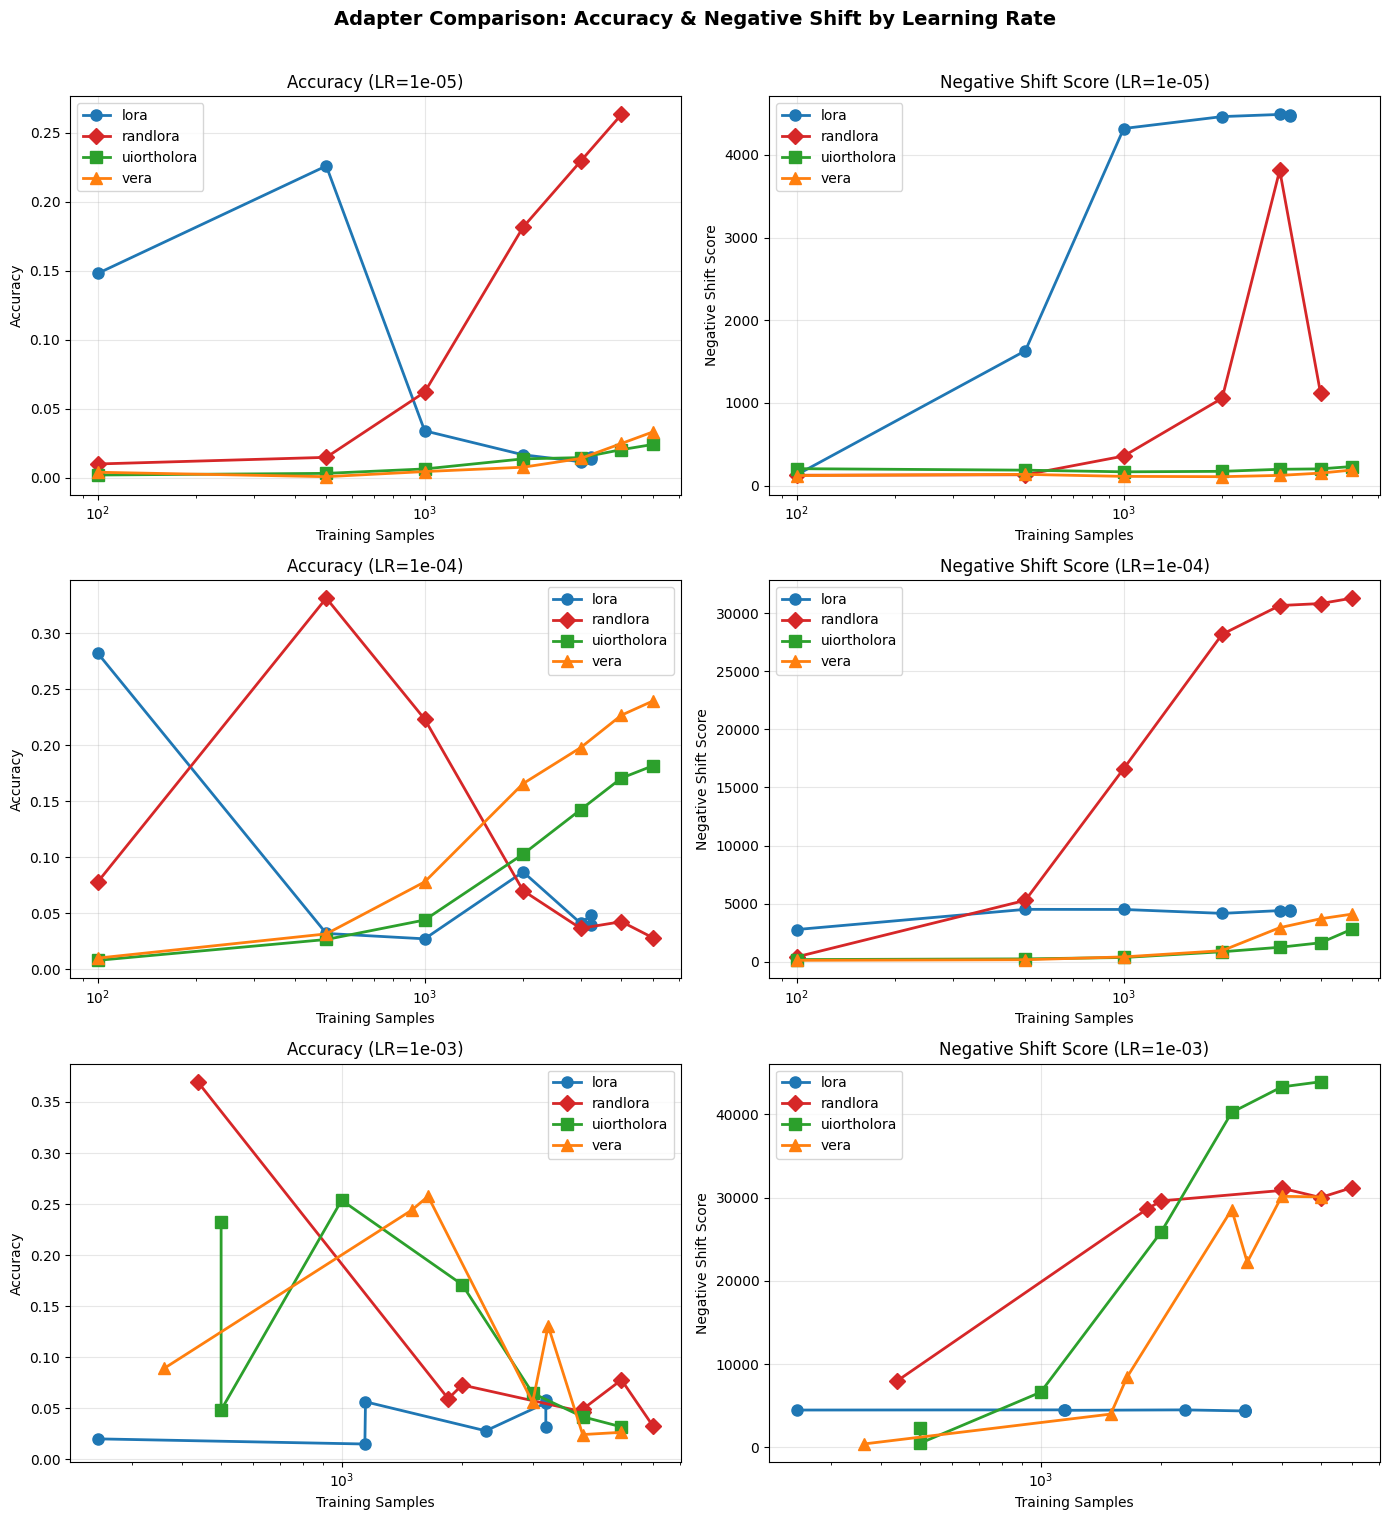


SUMMARY: Gemma-3-12B-IT - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.2820
  Negative Shift: 2771.6000
  Training Samples: 100
  Learning Rate: 1e-04

randlora:
  Best Accuracy: 0.3698
  Negative Shift: 7953.2000
  Training Samples: 437
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.2537
  Negative Shift: 6624.2000
  Training Samples: 1000
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.2575
  Negative Shift: 8448.2000
  Training Samples: 1644
  Learning Rate: 1e-03

SUMMARY: Gemma-3-12B-IT - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.1480
  Lowest Negative Shift: 131.4000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0100
  Lowest Negative Shift: 125.6000
  Training Samples: 100
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0064
  Lowest Negative Shift: 166.8000
  Training Samples: 1000
  Learning Rate: 1e-05

vera:
  Accuracy: 0.0076
  Lowest Negative Shift: 108.1000
  Training Sa

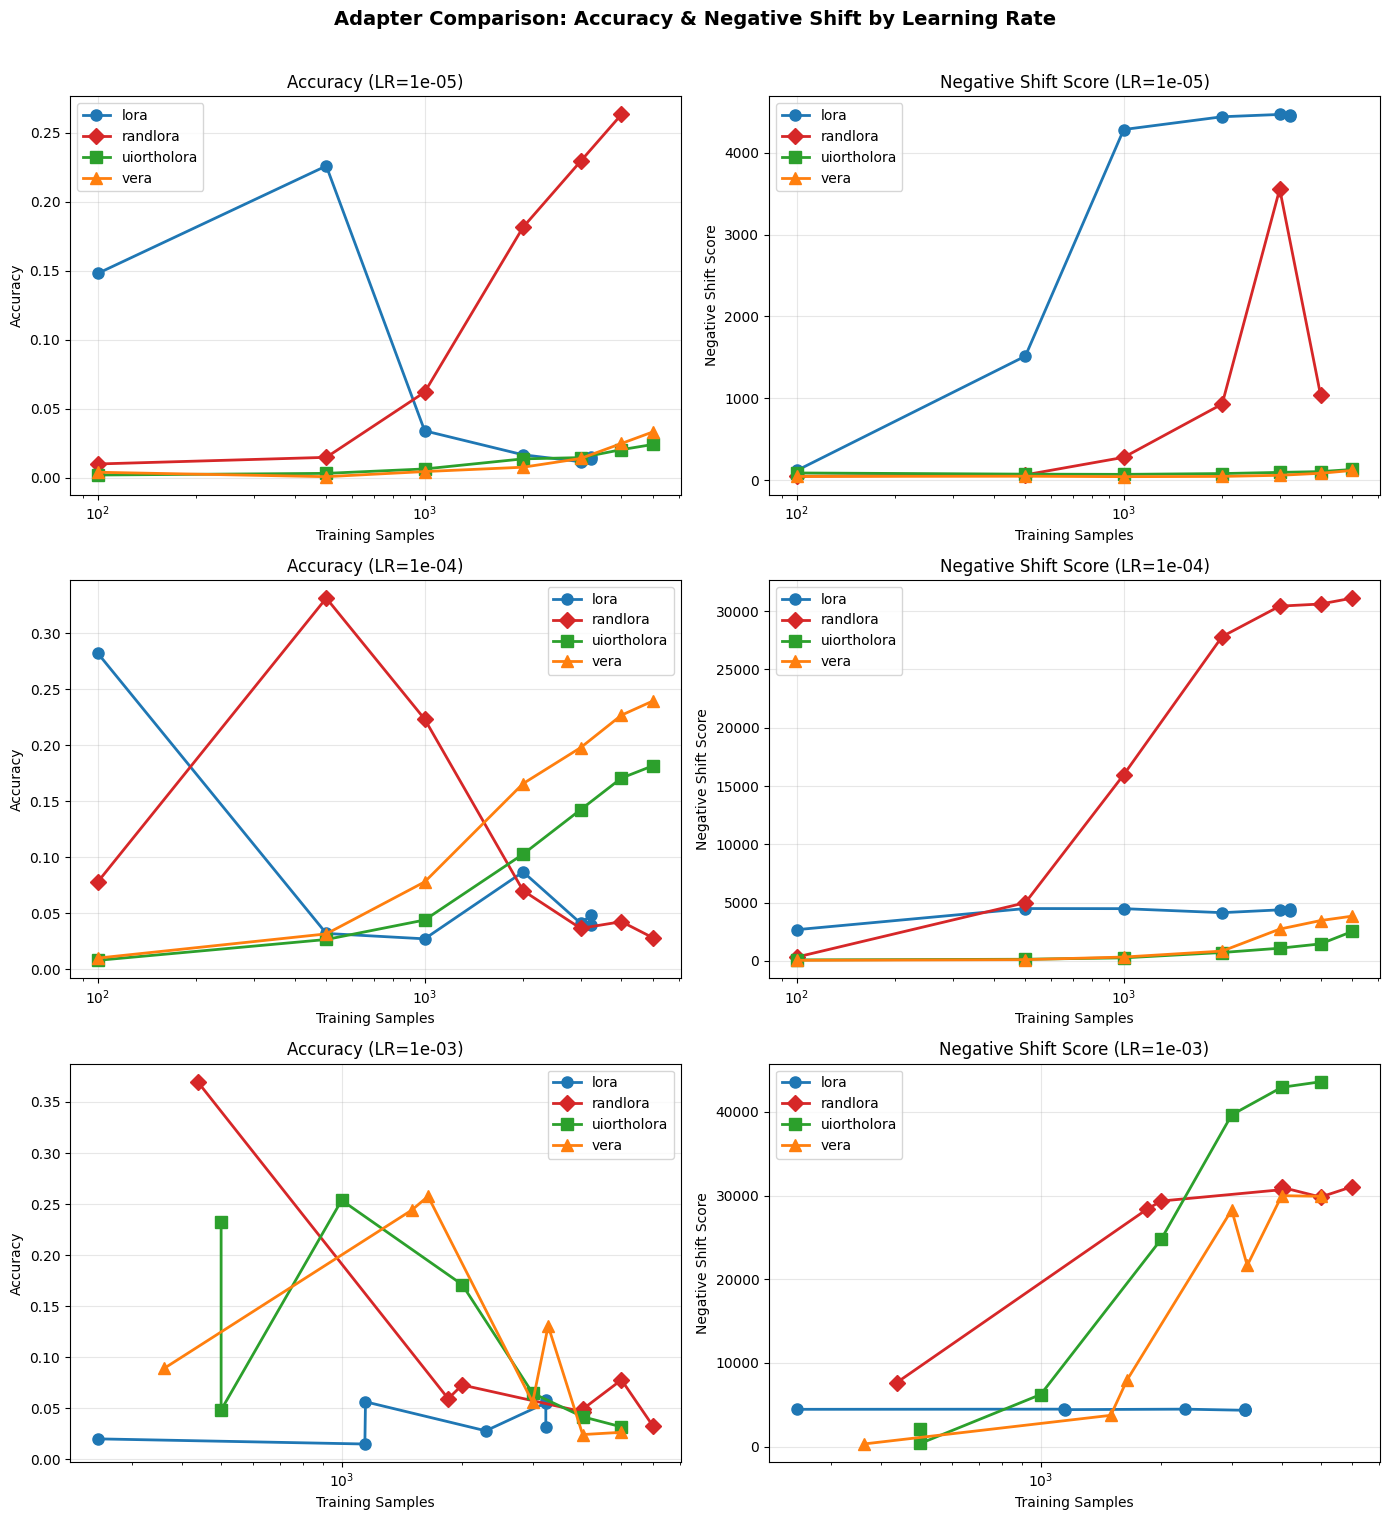


SUMMARY: Gemma-3-12B-IT - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.2820
  Negative Shift: 2676.6000
  Training Samples: 100
  Learning Rate: 1e-04

randlora:
  Best Accuracy: 0.3698
  Negative Shift: 7656.3000
  Training Samples: 437
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.2537
  Negative Shift: 6229.7000
  Training Samples: 1000
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.2575
  Negative Shift: 7979.3000
  Training Samples: 1644
  Learning Rate: 1e-03

SUMMARY: Gemma-3-12B-IT - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.1480
  Lowest Negative Shift: 117.0000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0100
  Lowest Negative Shift: 45.7000
  Training Samples: 100
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0064
  Lowest Negative Shift: 69.2000
  Training Samples: 1000
  Learning Rate: 1e-05

vera:
  Accuracy: 0.0045
  Lowest Negative Shift: 40.8000
  Training Sampl

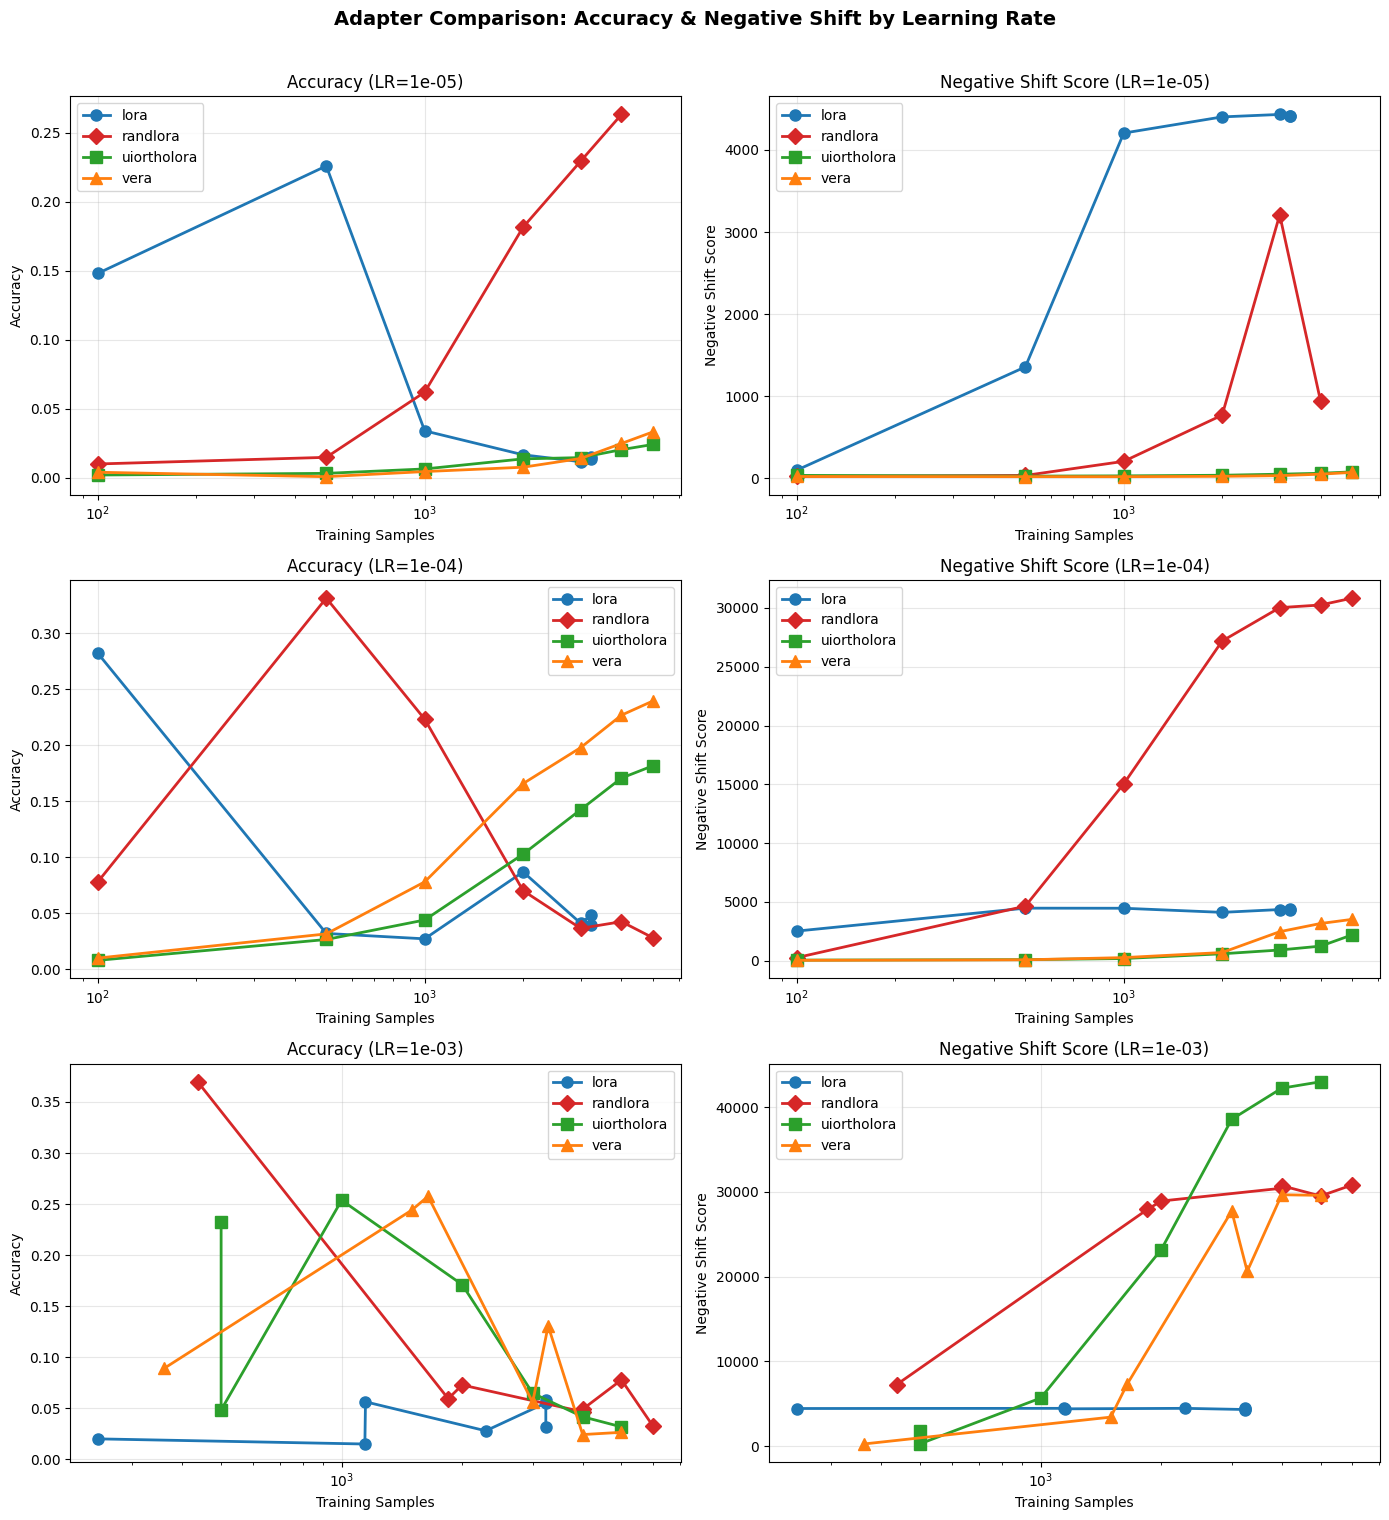


SUMMARY: Gemma-3-12B-IT - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.2820
  Negative Shift: 2507.7000
  Training Samples: 100
  Learning Rate: 1e-04

randlora:
  Best Accuracy: 0.3698
  Negative Shift: 7264.0000
  Training Samples: 437
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.2537
  Negative Shift: 5667.3000
  Training Samples: 1000
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.2575
  Negative Shift: 7297.5000
  Training Samples: 1644
  Learning Rate: 1e-03

SUMMARY: Gemma-3-12B-IT - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.1480
  Lowest Negative Shift: 98.5000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0100
  Lowest Negative Shift: 21.9000
  Training Samples: 100
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0032
  Lowest Negative Shift: 25.0000
  Training Samples: 500
  Learning Rate: 1e-05

vera:
  Accuracy: 0.0100
  Lowest Negative Shift: 17.3000
  Training Samples

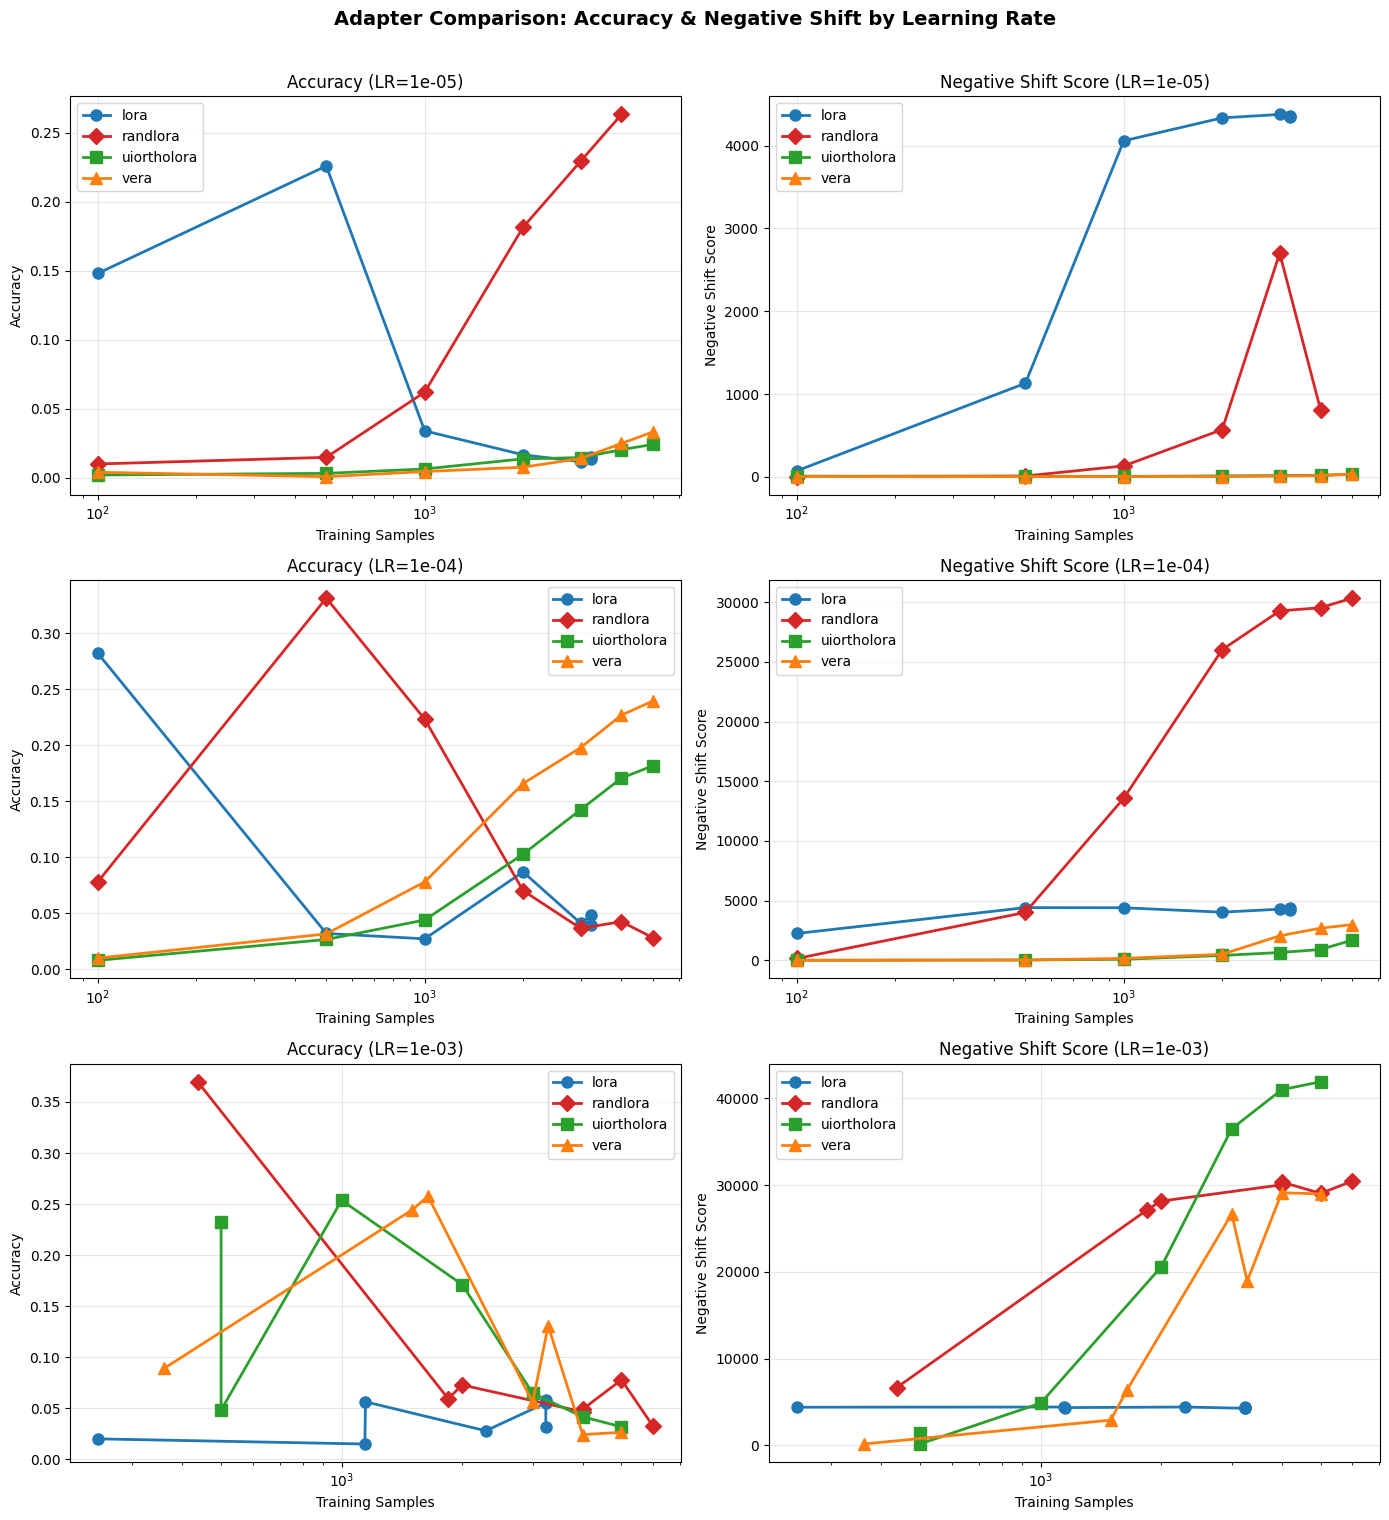


SUMMARY: Gemma-3-12B-IT - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.2820
  Negative Shift: 2251.5000
  Training Samples: 100
  Learning Rate: 1e-04

randlora:
  Best Accuracy: 0.3698
  Negative Shift: 6653.7000
  Training Samples: 437
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.2537
  Negative Shift: 4852.6000
  Training Samples: 1000
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.2575
  Negative Shift: 6398.3000
  Training Samples: 1644
  Learning Rate: 1e-03

SUMMARY: Gemma-3-12B-IT - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.1480
  Lowest Negative Shift: 72.4000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0100
  Lowest Negative Shift: 3.6000
  Training Samples: 100
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0032
  Lowest Negative Shift: 4.7000
  Training Samples: 500
  Learning Rate: 1e-05

vera:
  Accuracy: 0.0100
  Lowest Negative Shift: 0.9000
  Training Samples: 1

In [10]:
# ============================================================================
# GEMMA-3-12B-IT ANALYSIS
# ============================================================================

run_full_analysis(
    csv_path="adapters_results/threshold_0.2/adapter_results_gemma-3-12b-it.csv",
    output_prefix="graphs/gemma",
    model_name="Gemma-3-12B-IT"
)

run_full_analysis(
    csv_path="adapters_results/threshold_0.4/adapter_results_gemma-3-12b-it.csv",
    output_prefix="graphs/gemma",
    model_name="Gemma-3-12B-IT"
)

run_full_analysis(
    csv_path="adapters_results/threshold_0.6/adapter_results_gemma-3-12b-it.csv",
    output_prefix="graphs/gemma",
    model_name="Gemma-3-12B-IT"
)

run_full_analysis(
    csv_path="adapters_results/threshold_0.8/adapter_results_gemma-3-12b-it.csv",
    output_prefix="graphs/gemma",
    model_name="Gemma-3-12B-IT"
)


Running analysis for Llama-3.2-3B-Instruct
CSV: adapters_results/threshold_0.2/adapter_results_Llama-3.2-3B-Instruct.csv
Output prefix: graphs/llama-3-2-3b-instruct



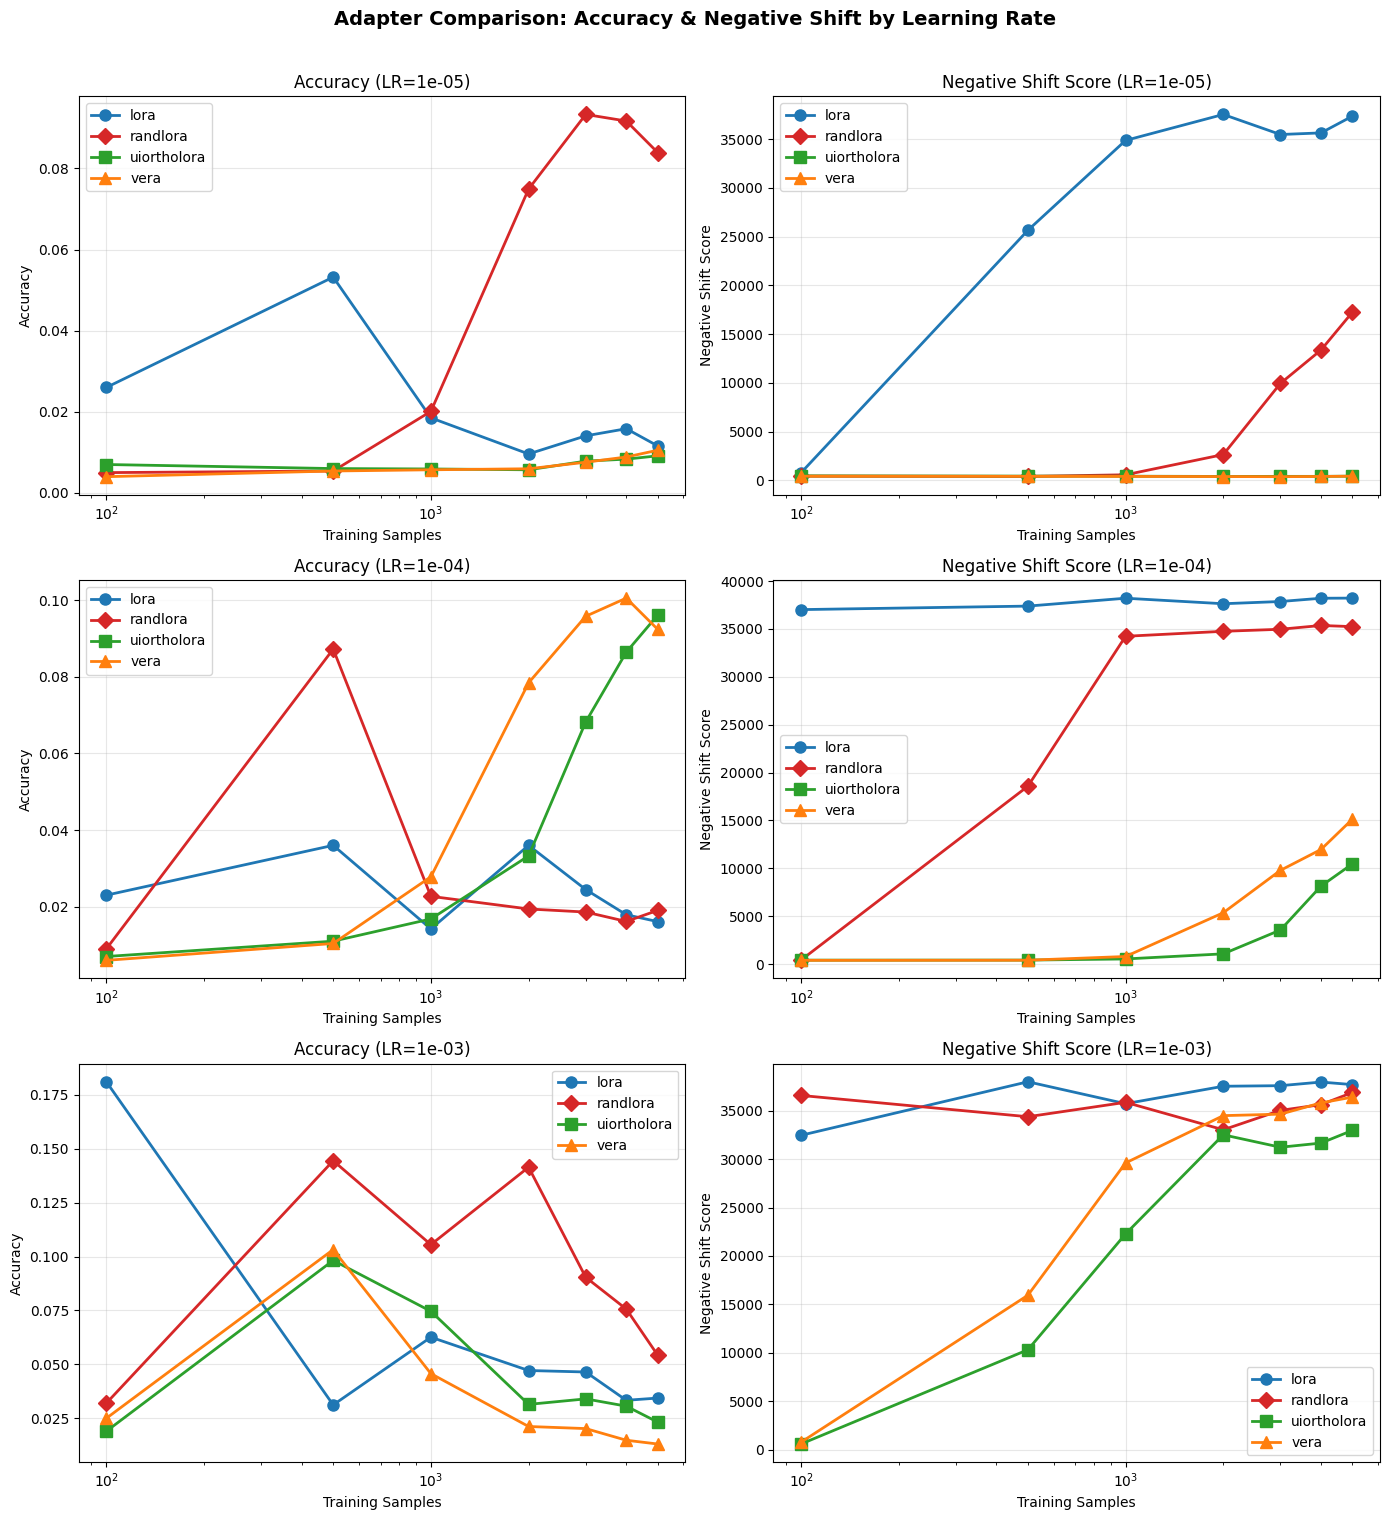


SUMMARY: Llama-3.2-3B-Instruct - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.1810
  Negative Shift: 32466.0000
  Training Samples: 100
  Learning Rate: 1e-03

randlora:
  Best Accuracy: 0.1444
  Negative Shift: 34385.5000
  Training Samples: 500
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.0982
  Negative Shift: 10307.2000
  Training Samples: 500
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.1032
  Negative Shift: 15940.0000
  Training Samples: 500
  Learning Rate: 1e-03

SUMMARY: Llama-3.2-3B-Instruct - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.0260
  Lowest Negative Shift: 772.4000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0054
  Lowest Negative Shift: 398.5000
  Training Samples: 500
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0057
  Lowest Negative Shift: 394.8000
  Training Samples: 2000
  Learning Rate: 1e-05

vera:
  Accuracy: 0.0076
  Lowest Negative Shift: 371.00

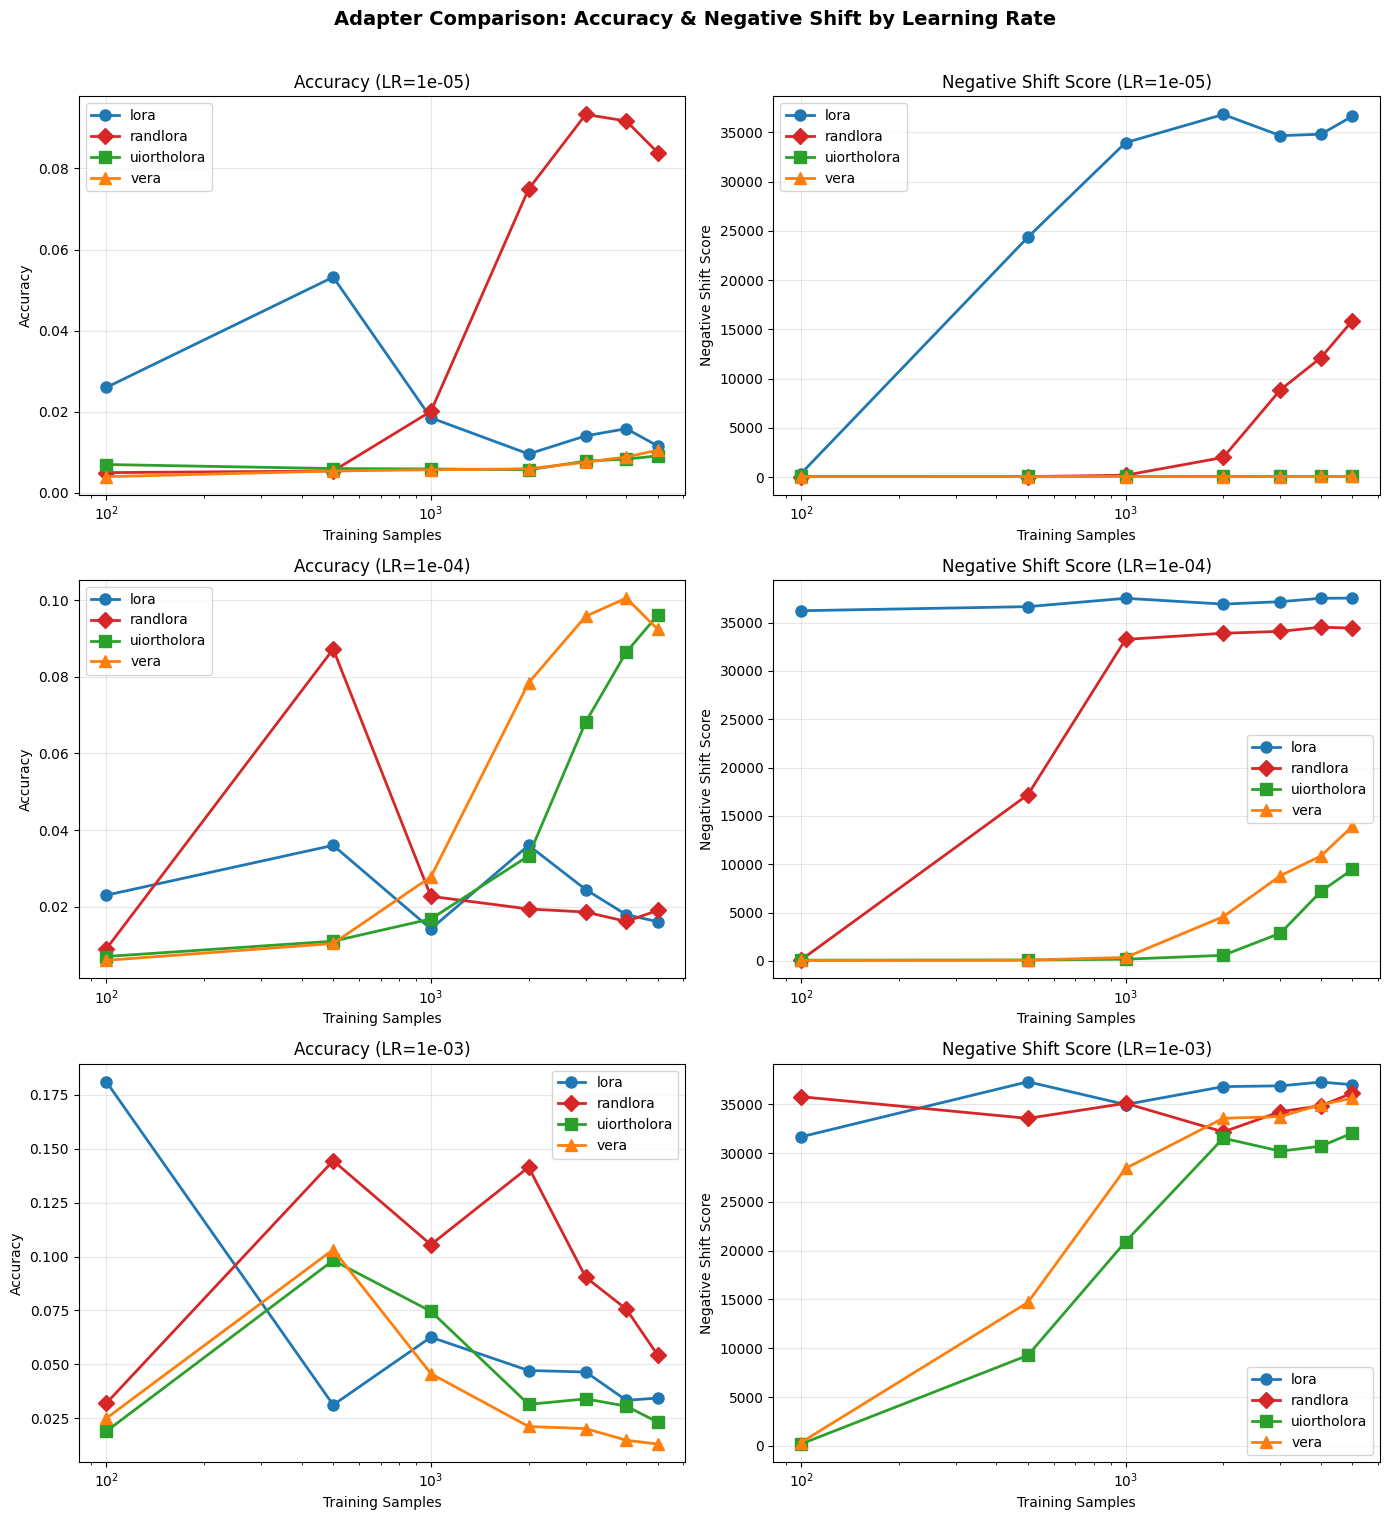


SUMMARY: Llama-3.2-3B-Instruct - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.1810
  Negative Shift: 31654.8000
  Training Samples: 100
  Learning Rate: 1e-03

randlora:
  Best Accuracy: 0.1444
  Negative Shift: 33547.2000
  Training Samples: 500
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.0982
  Negative Shift: 9278.3000
  Training Samples: 500
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.1032
  Negative Shift: 14703.2000
  Training Samples: 500
  Learning Rate: 1e-03

SUMMARY: Llama-3.2-3B-Instruct - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.0260
  Lowest Negative Shift: 367.4000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0054
  Lowest Negative Shift: 63.8000
  Training Samples: 500
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0070
  Lowest Negative Shift: 78.4000
  Training Samples: 100
  Learning Rate: 1e-04

vera:
  Accuracy: 0.0060
  Lowest Negative Shift: 58.0000
  

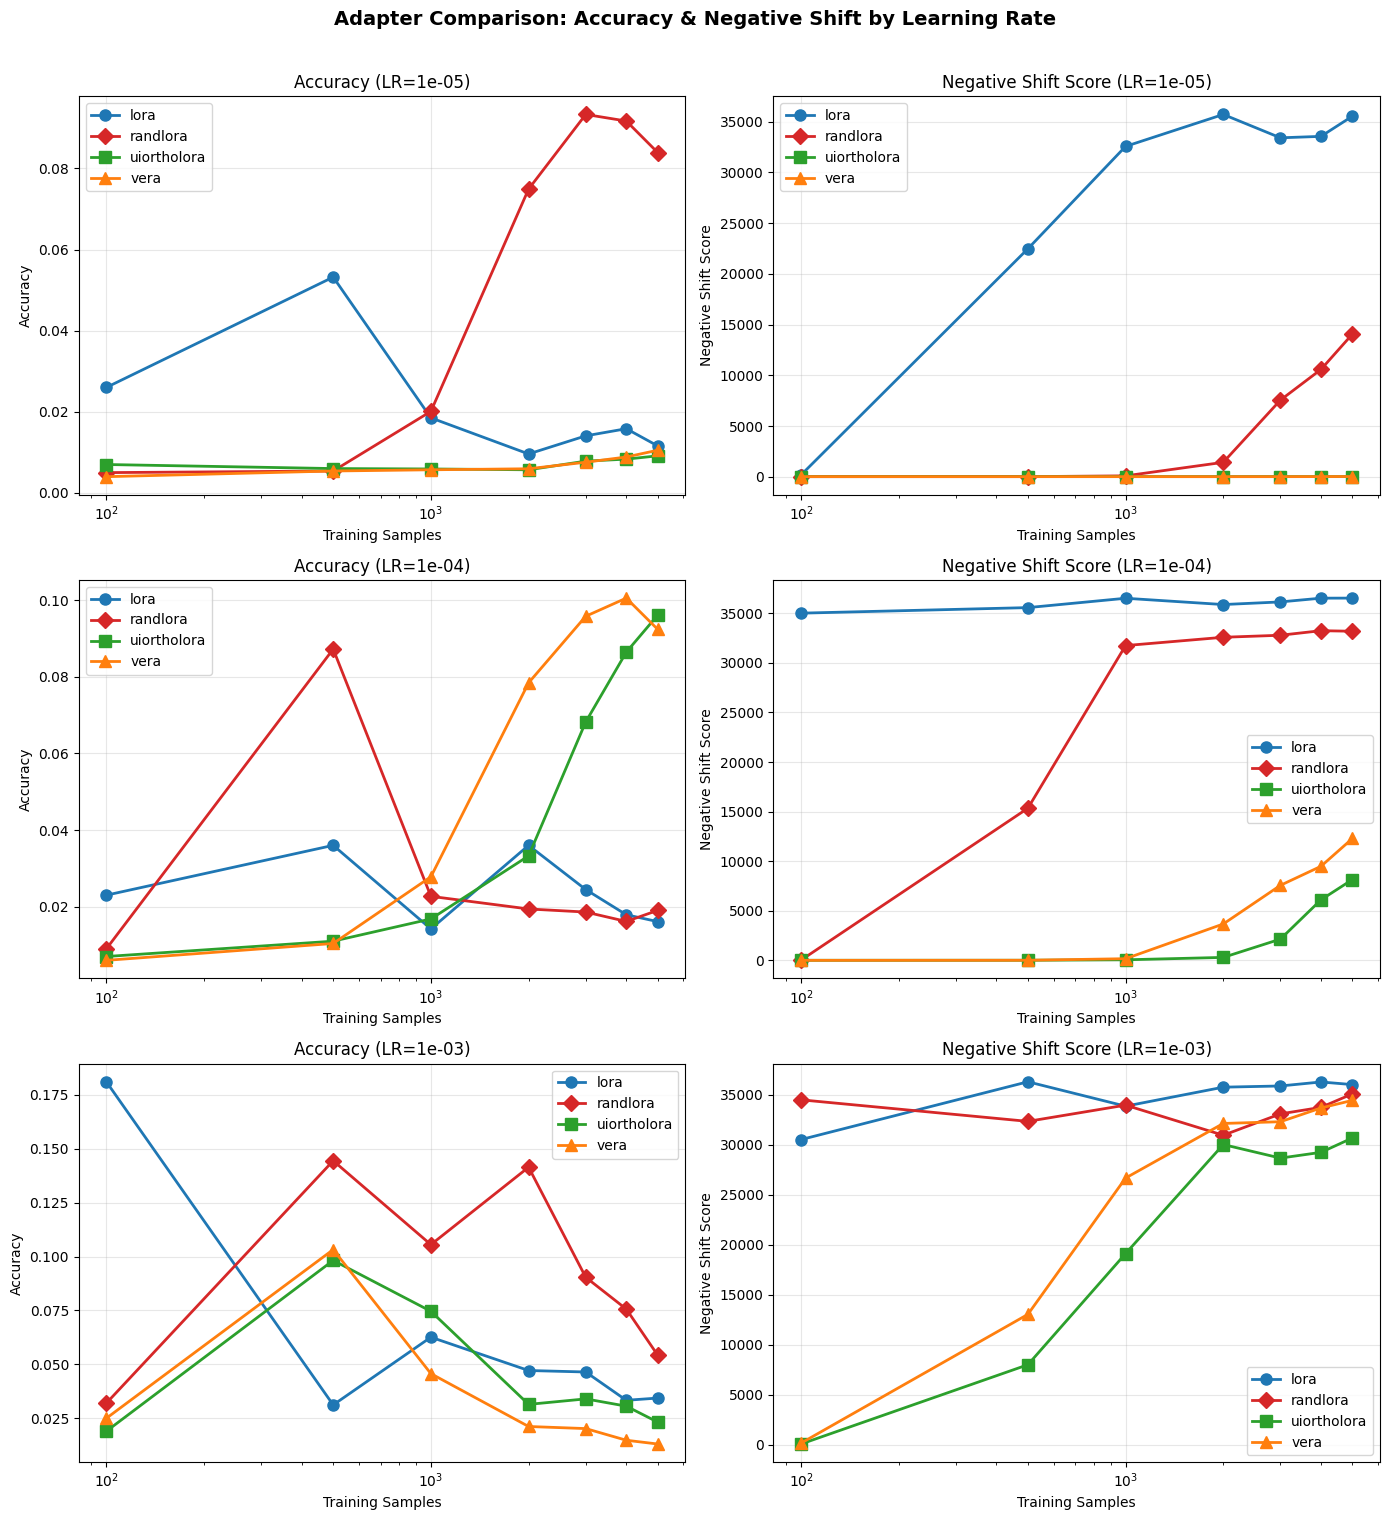


SUMMARY: Llama-3.2-3B-Instruct - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.1810
  Negative Shift: 30507.2000
  Training Samples: 100
  Learning Rate: 1e-03

randlora:
  Best Accuracy: 0.1444
  Negative Shift: 32326.6000
  Training Samples: 500
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.0982
  Negative Shift: 8005.8000
  Training Samples: 500
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.1032
  Negative Shift: 13039.6000
  Training Samples: 500
  Learning Rate: 1e-03

SUMMARY: Llama-3.2-3B-Instruct - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.0260
  Lowest Negative Shift: 177.7000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0050
  Lowest Negative Shift: 11.6000
  Training Samples: 100
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0070
  Lowest Negative Shift: 13.0000
  Training Samples: 100
  Learning Rate: 1e-05

vera:
  Accuracy: 0.0060
  Lowest Negative Shift: 9.2000
  T

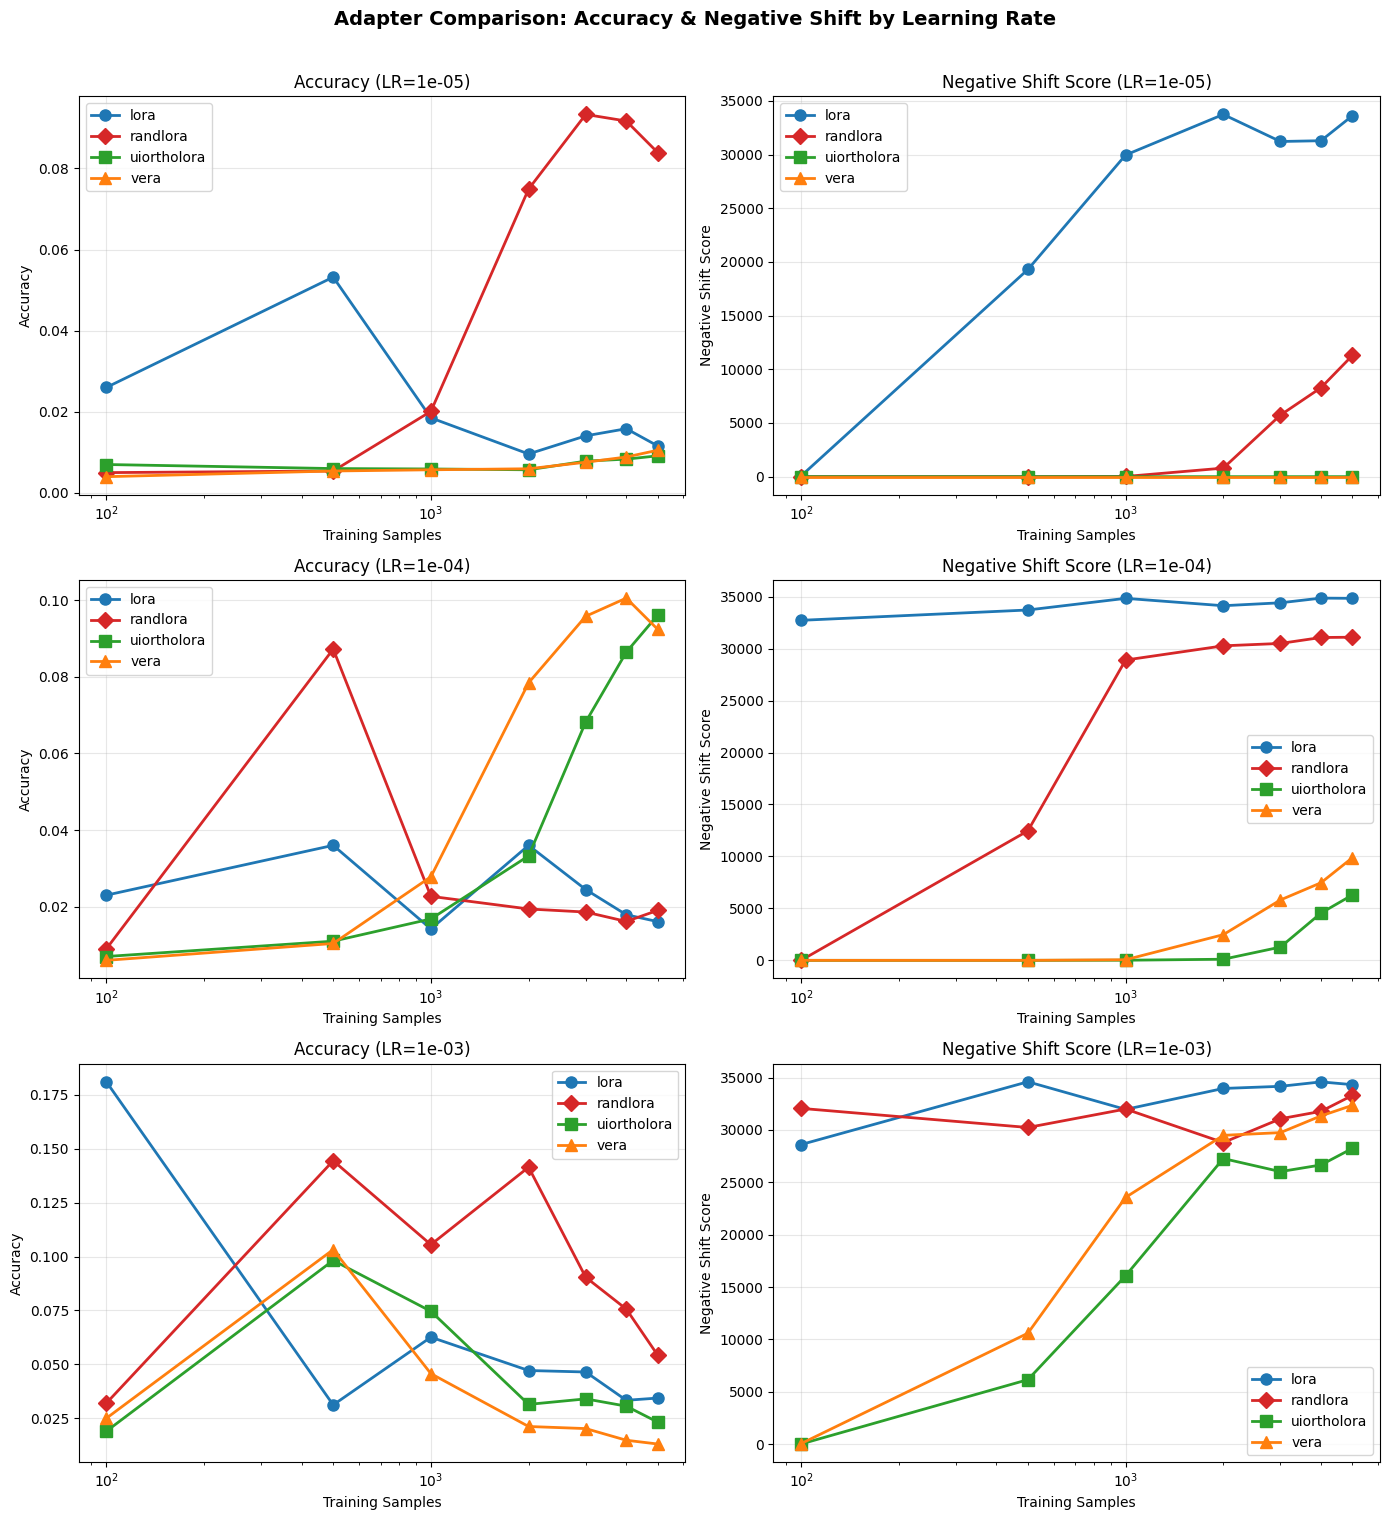


SUMMARY: Llama-3.2-3B-Instruct - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.1810
  Negative Shift: 28603.4000
  Training Samples: 100
  Learning Rate: 1e-03

randlora:
  Best Accuracy: 0.1444
  Negative Shift: 30235.2000
  Training Samples: 500
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.0982
  Negative Shift: 6158.7000
  Training Samples: 500
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.1032
  Negative Shift: 10593.1000
  Training Samples: 500
  Learning Rate: 1e-03

SUMMARY: Llama-3.2-3B-Instruct - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.0260
  Lowest Negative Shift: 61.4000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0090
  Lowest Negative Shift: 0.0000
  Training Samples: 100
  Learning Rate: 1e-04

uiortholora:
  Accuracy: 0.0070
  Lowest Negative Shift: 0.0000
  Training Samples: 100
  Learning Rate: 1e-04

vera:
  Accuracy: 0.0060
  Lowest Negative Shift: 0.0000
  Trai

In [13]:
# ============================================================================
# LLAMA-3.2-3B-INSTRUCT ANALYSIS
# ============================================================================

run_full_analysis(
    csv_path="adapters_results/threshold_0.2/adapter_results_Llama-3.2-3B-Instruct.csv",
    output_prefix="graphs/llama-3-2-3b-instruct",
    model_name="Llama-3.2-3B-Instruct"
)

run_full_analysis(
    csv_path="adapters_results/threshold_0.4/adapter_results_Llama-3.2-3B-Instruct.csv",
    output_prefix="graphs/llama-3-2-3b-instruct",
    model_name="Llama-3.2-3B-Instruct"
)

run_full_analysis(
    csv_path="adapters_results/threshold_0.6/adapter_results_Llama-3.2-3B-Instruct.csv",
    output_prefix="graphs/llama-3-2-3b-instruct",
    model_name="Llama-3.2-3B-Instruct"
)

run_full_analysis(
    csv_path="adapters_results/threshold_0.8/adapter_results_Llama-3.2-3B-Instruct.csv",
    output_prefix="graphs/llama-3-2-3b-instruct",
    model_name="Llama-3.2-3B-Instruct"
)


Running analysis for Llama-3.1-8B-Instruct
CSV: adapters_results/threshold_0.2/adapter_results_Llama-3.1-8B-Instruct.csv
Output prefix: graphs/llama-3-1-8b-instruct



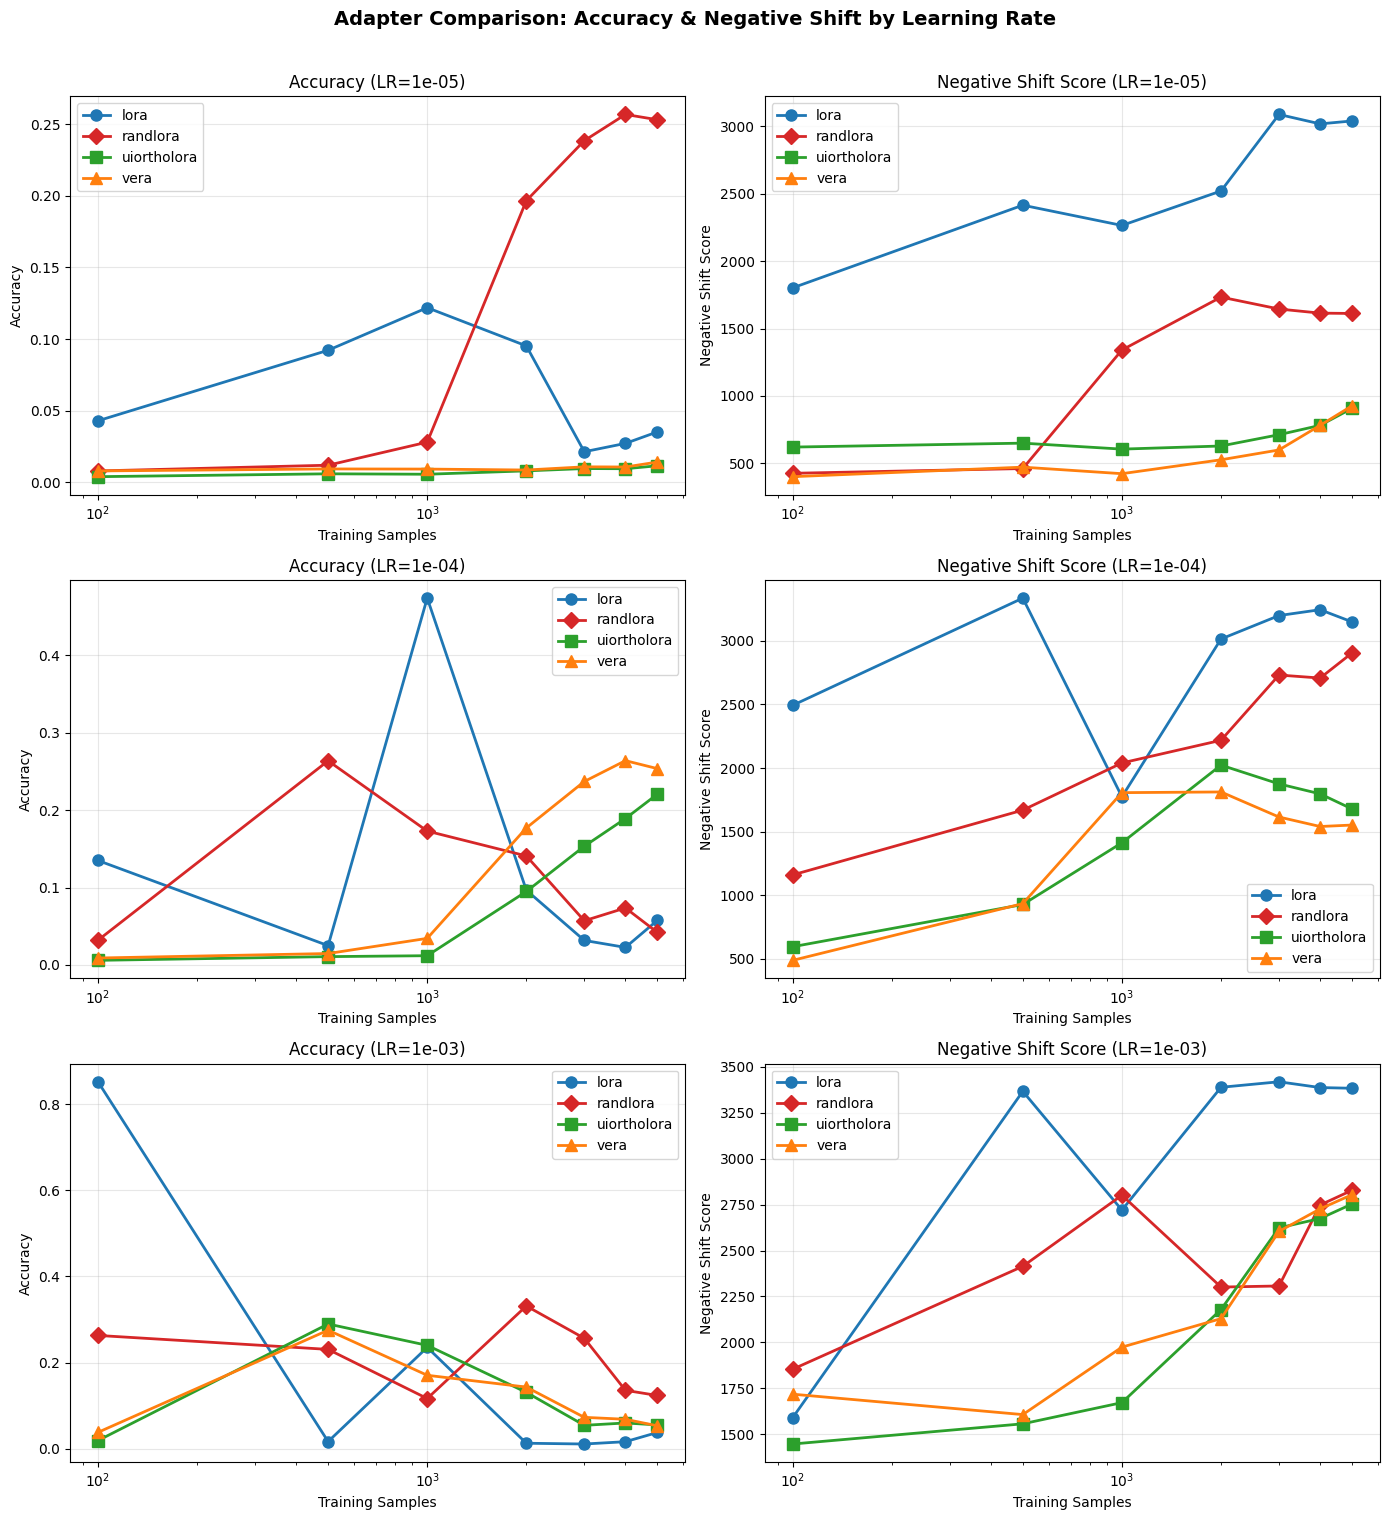


SUMMARY: Llama-3.1-8B-Instruct - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.8520
  Negative Shift: 1590.4000
  Training Samples: 100
  Learning Rate: 1e-03

randlora:
  Best Accuracy: 0.3314
  Negative Shift: 2301.3000
  Training Samples: 2000
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.2896
  Negative Shift: 1557.1000
  Training Samples: 500
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.2752
  Negative Shift: 1607.3000
  Training Samples: 500
  Learning Rate: 1e-03

SUMMARY: Llama-3.1-8B-Instruct - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.8520
  Lowest Negative Shift: 1590.4000
  Training Samples: 100
  Learning Rate: 1e-03

randlora:
  Accuracy: 0.0080
  Lowest Negative Shift: 426.5000
  Training Samples: 100
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0060
  Lowest Negative Shift: 596.3000
  Training Samples: 100
  Learning Rate: 1e-04

vera:
  Accuracy: 0.0080
  Lowest Negative Shift: 401.4000


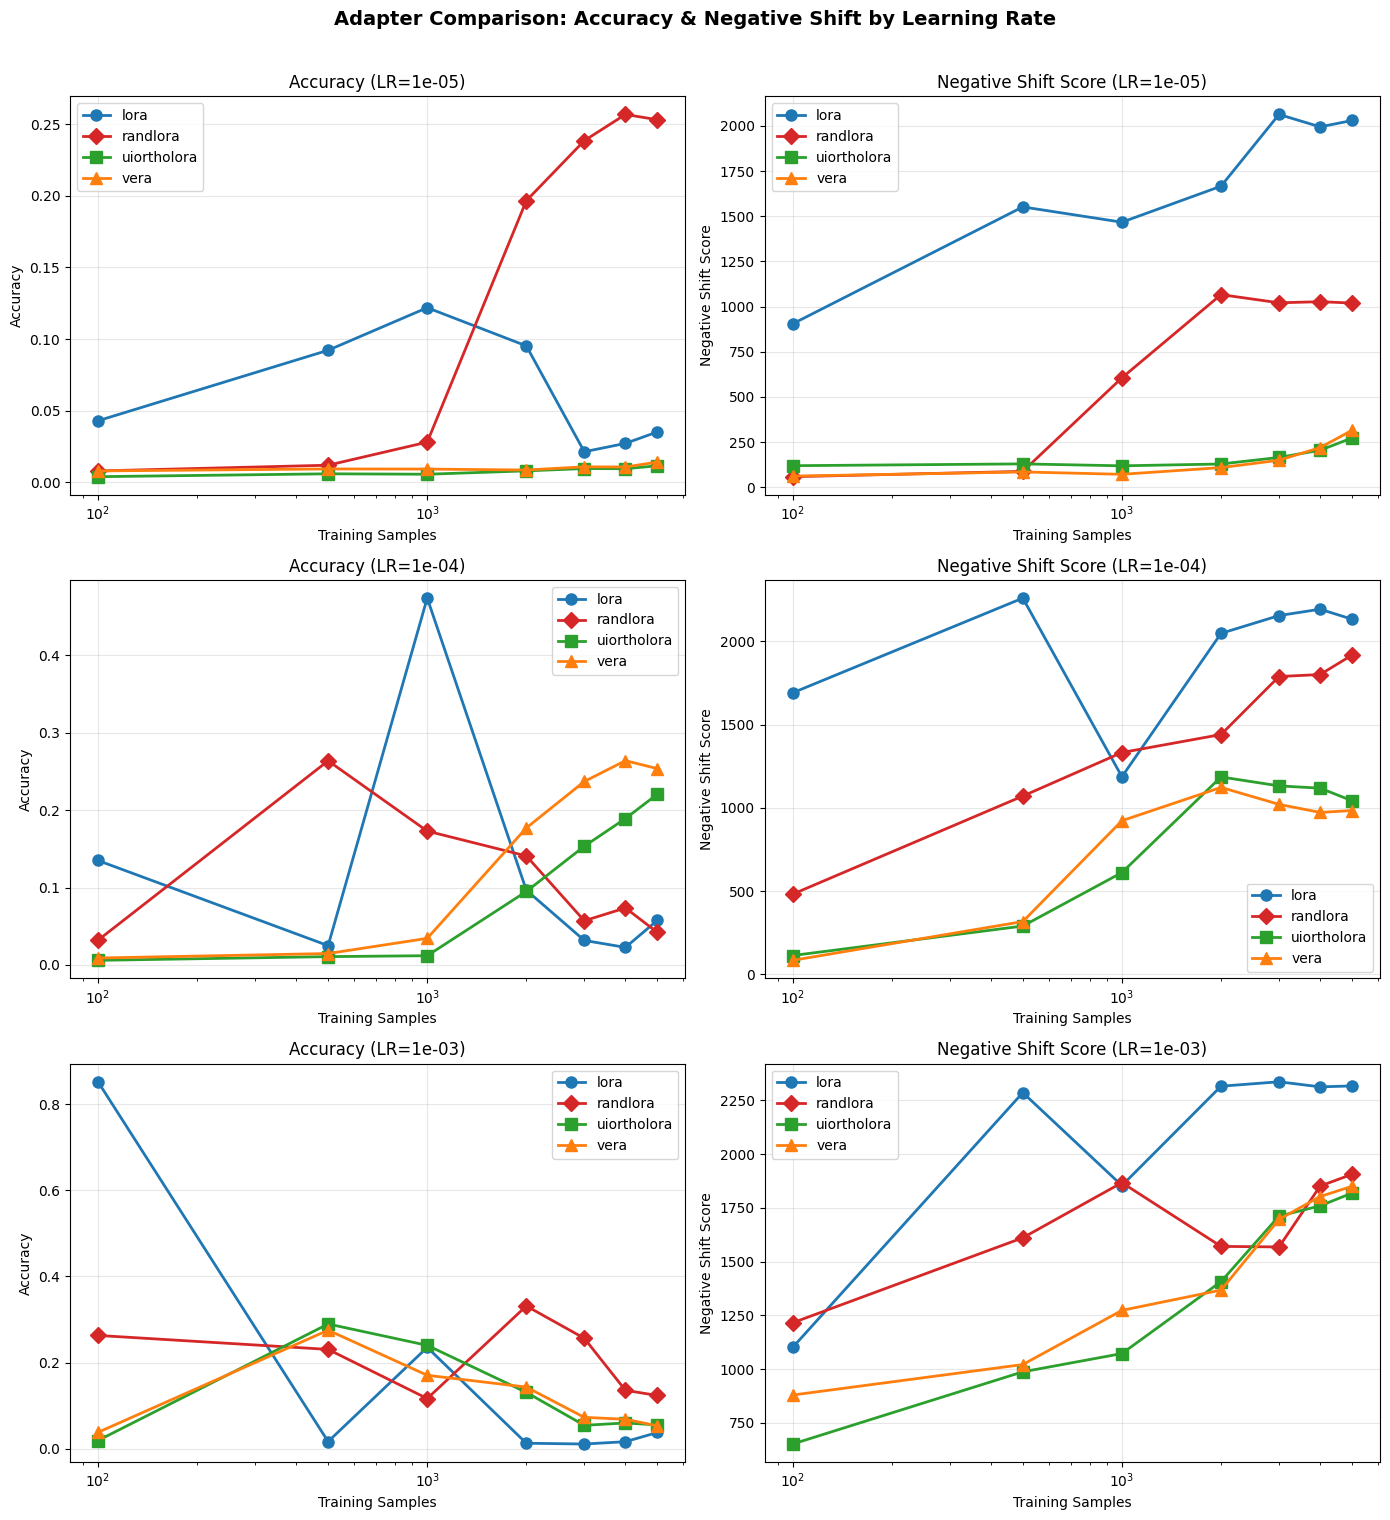


SUMMARY: Llama-3.1-8B-Instruct - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.8520
  Negative Shift: 1100.7000
  Training Samples: 100
  Learning Rate: 1e-03

randlora:
  Best Accuracy: 0.3314
  Negative Shift: 1570.6000
  Training Samples: 2000
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.2896
  Negative Shift: 987.2000
  Training Samples: 500
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.2752
  Negative Shift: 1021.0000
  Training Samples: 500
  Learning Rate: 1e-03

SUMMARY: Llama-3.1-8B-Instruct - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.0430
  Lowest Negative Shift: 904.6000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0080
  Lowest Negative Shift: 58.3000
  Training Samples: 100
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0060
  Lowest Negative Shift: 113.7000
  Training Samples: 100
  Learning Rate: 1e-04

vera:
  Accuracy: 0.0080
  Lowest Negative Shift: 61.4000
  Tr

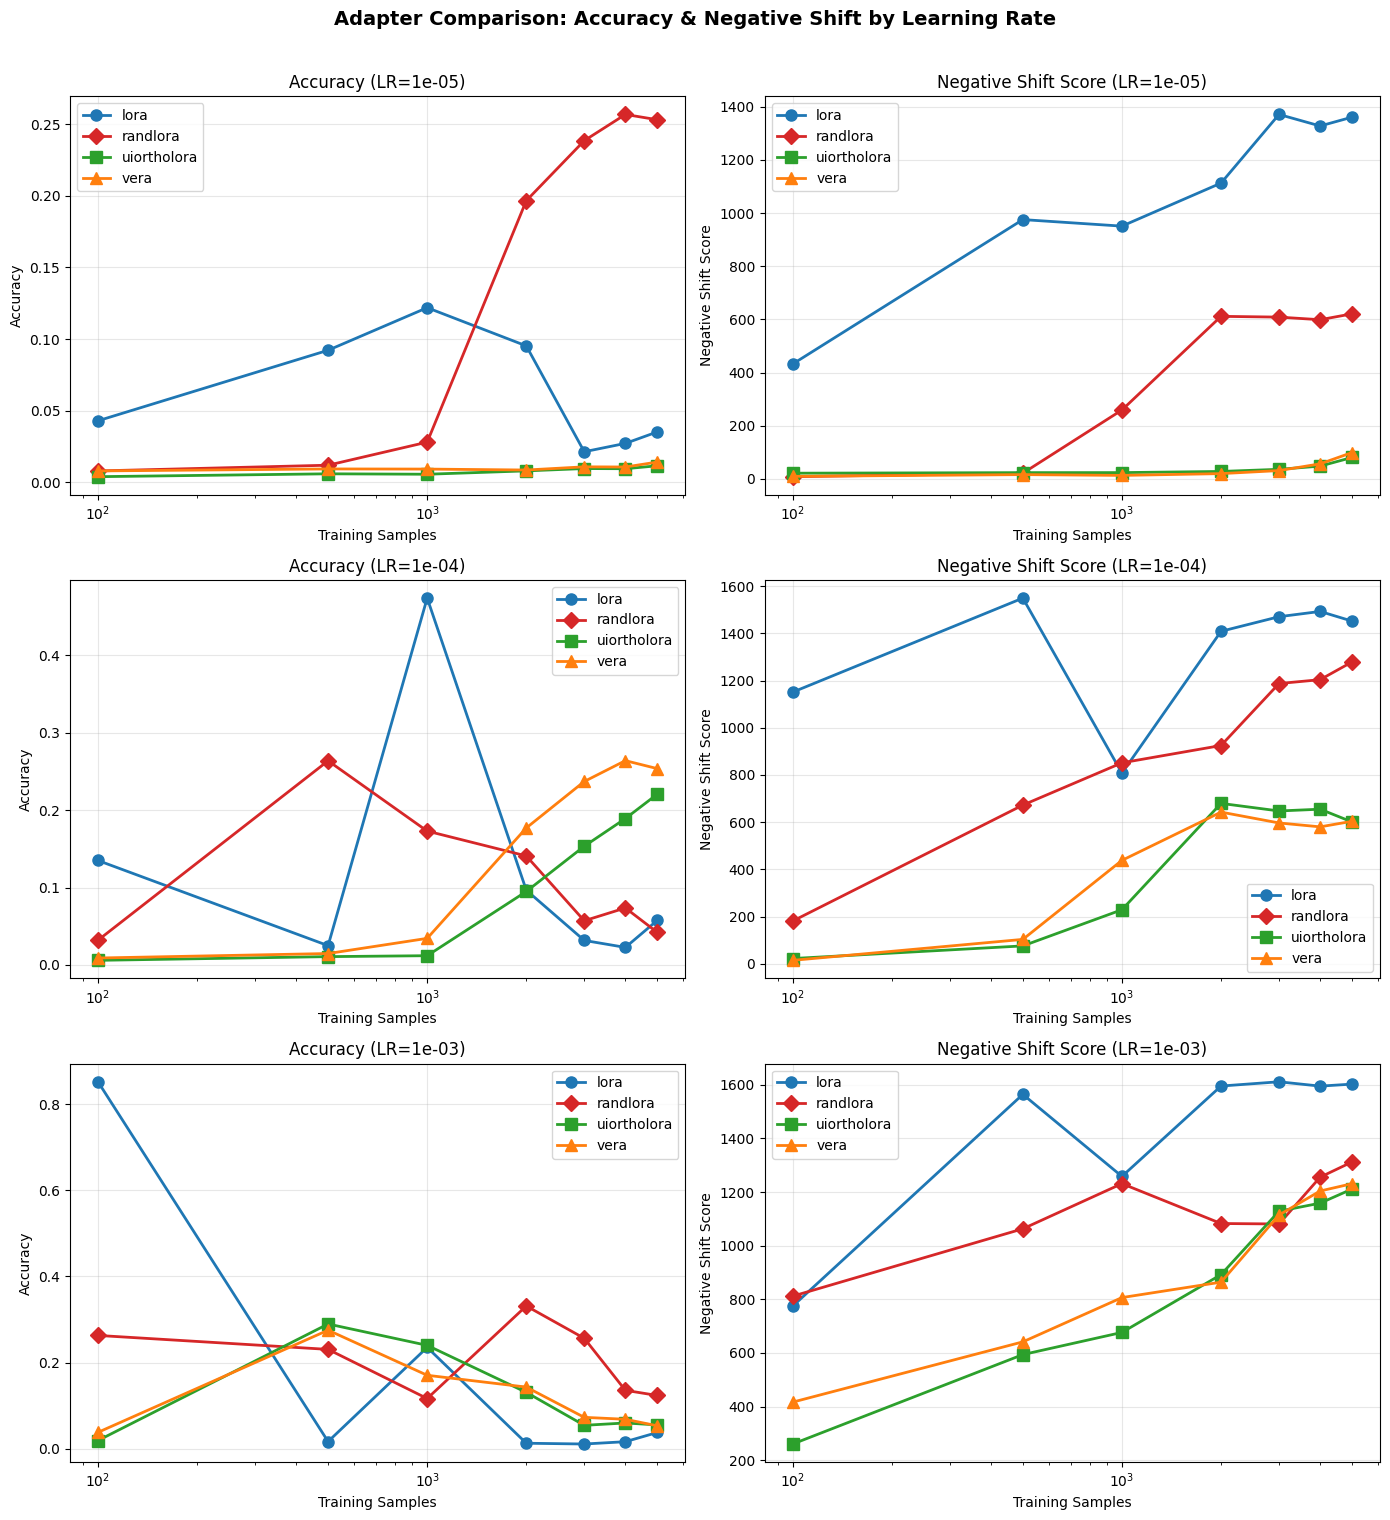


SUMMARY: Llama-3.1-8B-Instruct - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.8520
  Negative Shift: 774.7000
  Training Samples: 100
  Learning Rate: 1e-03

randlora:
  Best Accuracy: 0.3314
  Negative Shift: 1082.8000
  Training Samples: 2000
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.2896
  Negative Shift: 593.8000
  Training Samples: 500
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.2752
  Negative Shift: 641.3000
  Training Samples: 500
  Learning Rate: 1e-03

SUMMARY: Llama-3.1-8B-Instruct - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.0430
  Lowest Negative Shift: 432.2000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0080
  Lowest Negative Shift: 8.1000
  Training Samples: 100
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0040
  Lowest Negative Shift: 21.2000
  Training Samples: 100
  Learning Rate: 1e-05

vera:
  Accuracy: 0.0080
  Lowest Negative Shift: 9.3000
  Trainin

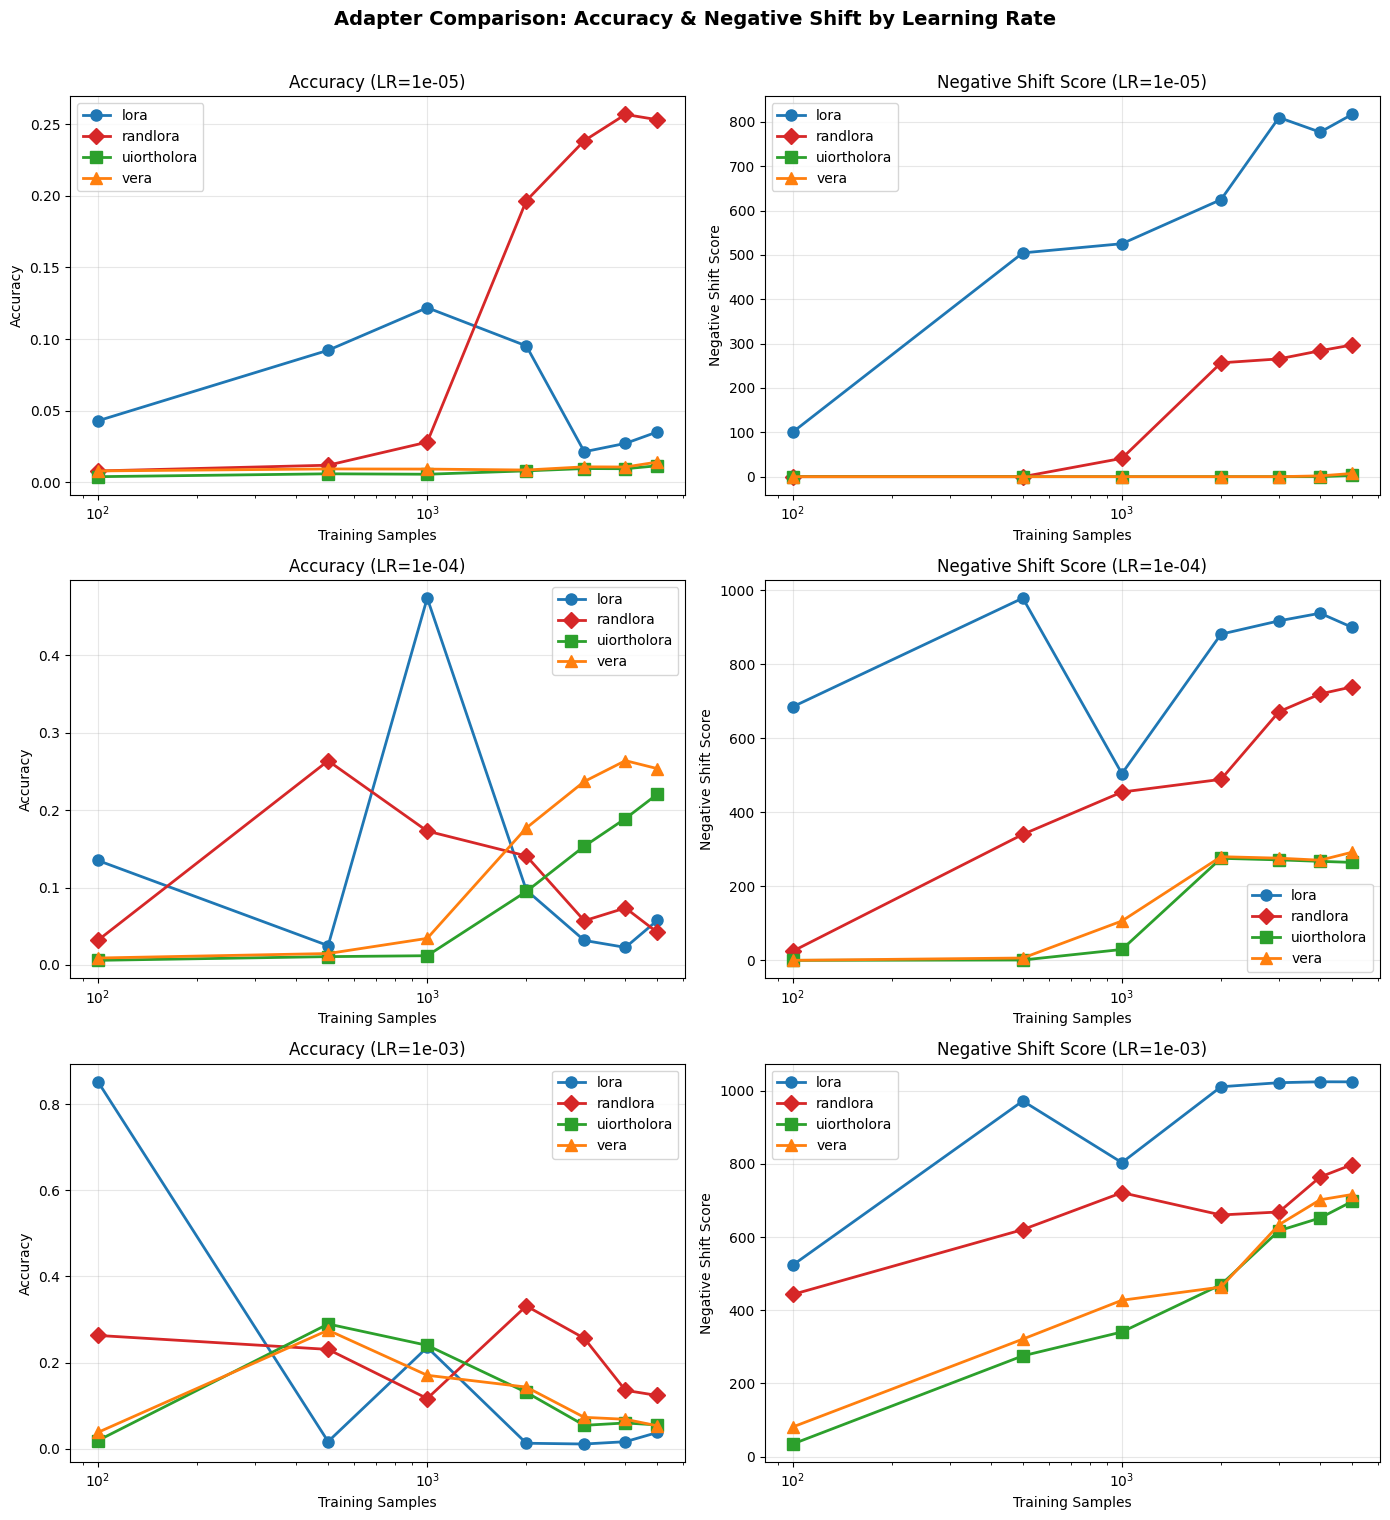


SUMMARY: Llama-3.1-8B-Instruct - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.8520
  Negative Shift: 523.5000
  Training Samples: 100
  Learning Rate: 1e-03

randlora:
  Best Accuracy: 0.3314
  Negative Shift: 660.6000
  Training Samples: 2000
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.2896
  Negative Shift: 275.6000
  Training Samples: 500
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.2752
  Negative Shift: 321.3000
  Training Samples: 500
  Learning Rate: 1e-03

SUMMARY: Llama-3.1-8B-Instruct - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.0430
  Lowest Negative Shift: 100.4000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0080
  Lowest Negative Shift: 0.0000
  Training Samples: 100
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0060
  Lowest Negative Shift: 0.0000
  Training Samples: 100
  Learning Rate: 1e-04

vera:
  Accuracy: 0.0090
  Lowest Negative Shift: 0.0000
  Training 

In [12]:
# ============================================================================
# LLAMA-3.2-3B-INSTRUCT ANALYSIS
# ============================================================================

run_full_analysis(
    csv_path="adapters_results/threshold_0.2/adapter_results_Llama-3.1-8B-Instruct.csv",
    output_prefix="graphs/llama-3-1-8b-instruct",
    model_name="Llama-3.1-8B-Instruct"
)

run_full_analysis(
    csv_path="adapters_results/threshold_0.4/adapter_results_Llama-3.1-8B-Instruct.csv",
    output_prefix="graphs/llama-3-1-8b-instruct",
    model_name="Llama-3.1-8B-Instruct"
)

run_full_analysis(
    csv_path="adapters_results/threshold_0.6/adapter_results_Llama-3.1-8B-Instruct.csv",
    output_prefix="graphs/llama-3-1-8b-instruct",
    model_name="Llama-3.1-8B-Instruct"
)

run_full_analysis(
    csv_path="adapters_results/threshold_0.8/adapter_results_Llama-3.1-8B-Instruct.csv",
    output_prefix="graphs/llama-3-1-8b-instruct",
    model_name="Llama-3.1-8B-Instruct"
)


THRESHOLD = 0.2


Gemma-3-12B-IT
----------------------------------------------------------------------------------------------------

Average Accuracy by Adapter & LR:
lr            0.00001  0.00010  0.00100
adapter_type                           
lora           0.0664   0.0795   0.0376
randlora       0.1268   0.1157   0.1010
uiortholora    0.0121   0.0966   0.1204
vera           0.0127   0.1356   0.1182


Average Negative Shift Score by Adapter & LR:
lr             0.00001    0.00010    0.00100
adapter_type                                
lora         3426.7571  4161.2000  4451.7429
randlora     1100.7167 20471.5143 27066.8571
uiortholora   194.6857  1047.7429 23258.3571
vera          134.4286  1770.1429 17702.6571



Llama-3.1-8B-Instruct
----------------------------------------------------------------------------------------------------

Average Accuracy by Adapter & LR:
lr            0.00001  0.00010  0.00100
adapter_type                           
lora           0.0623   0.1204 

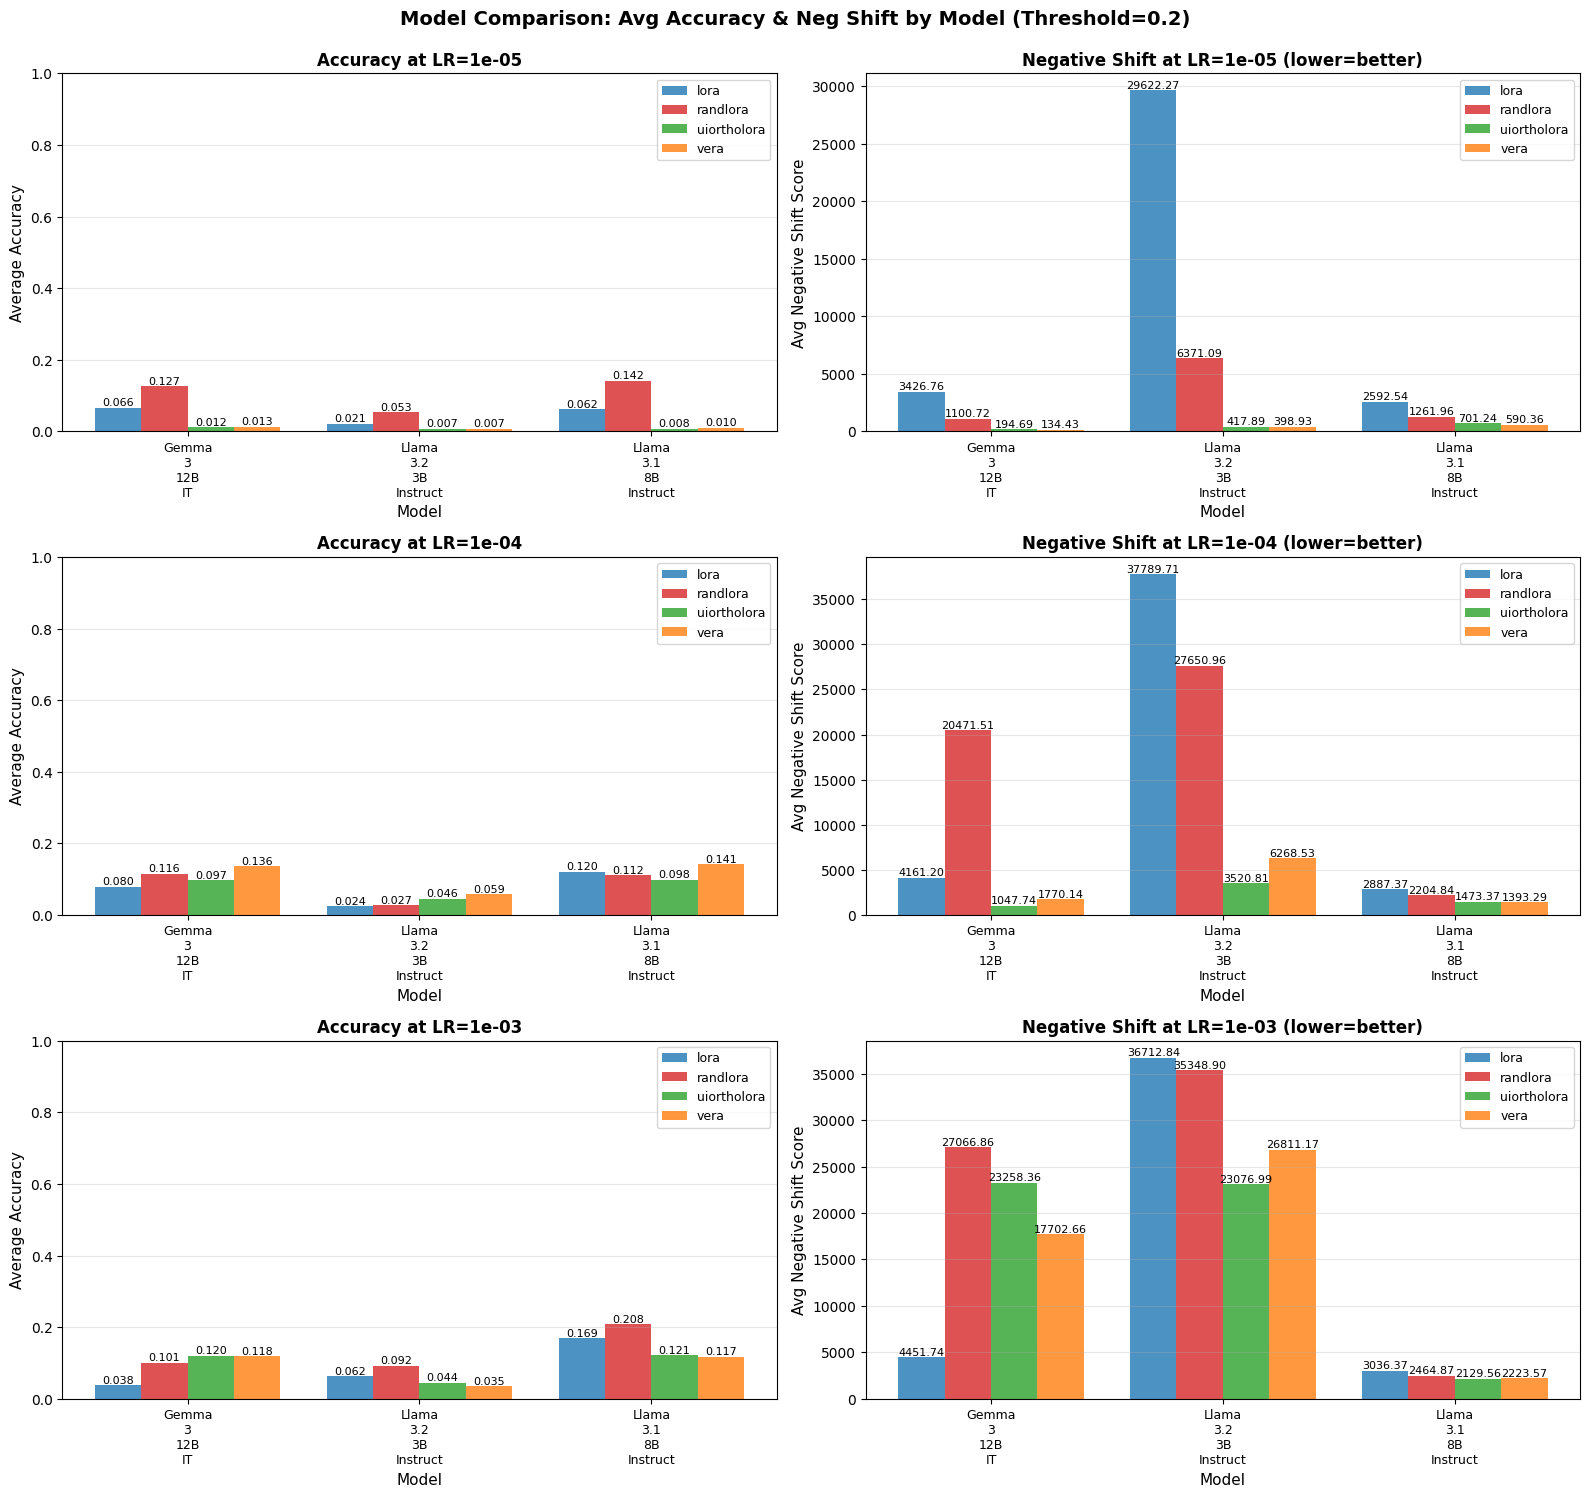

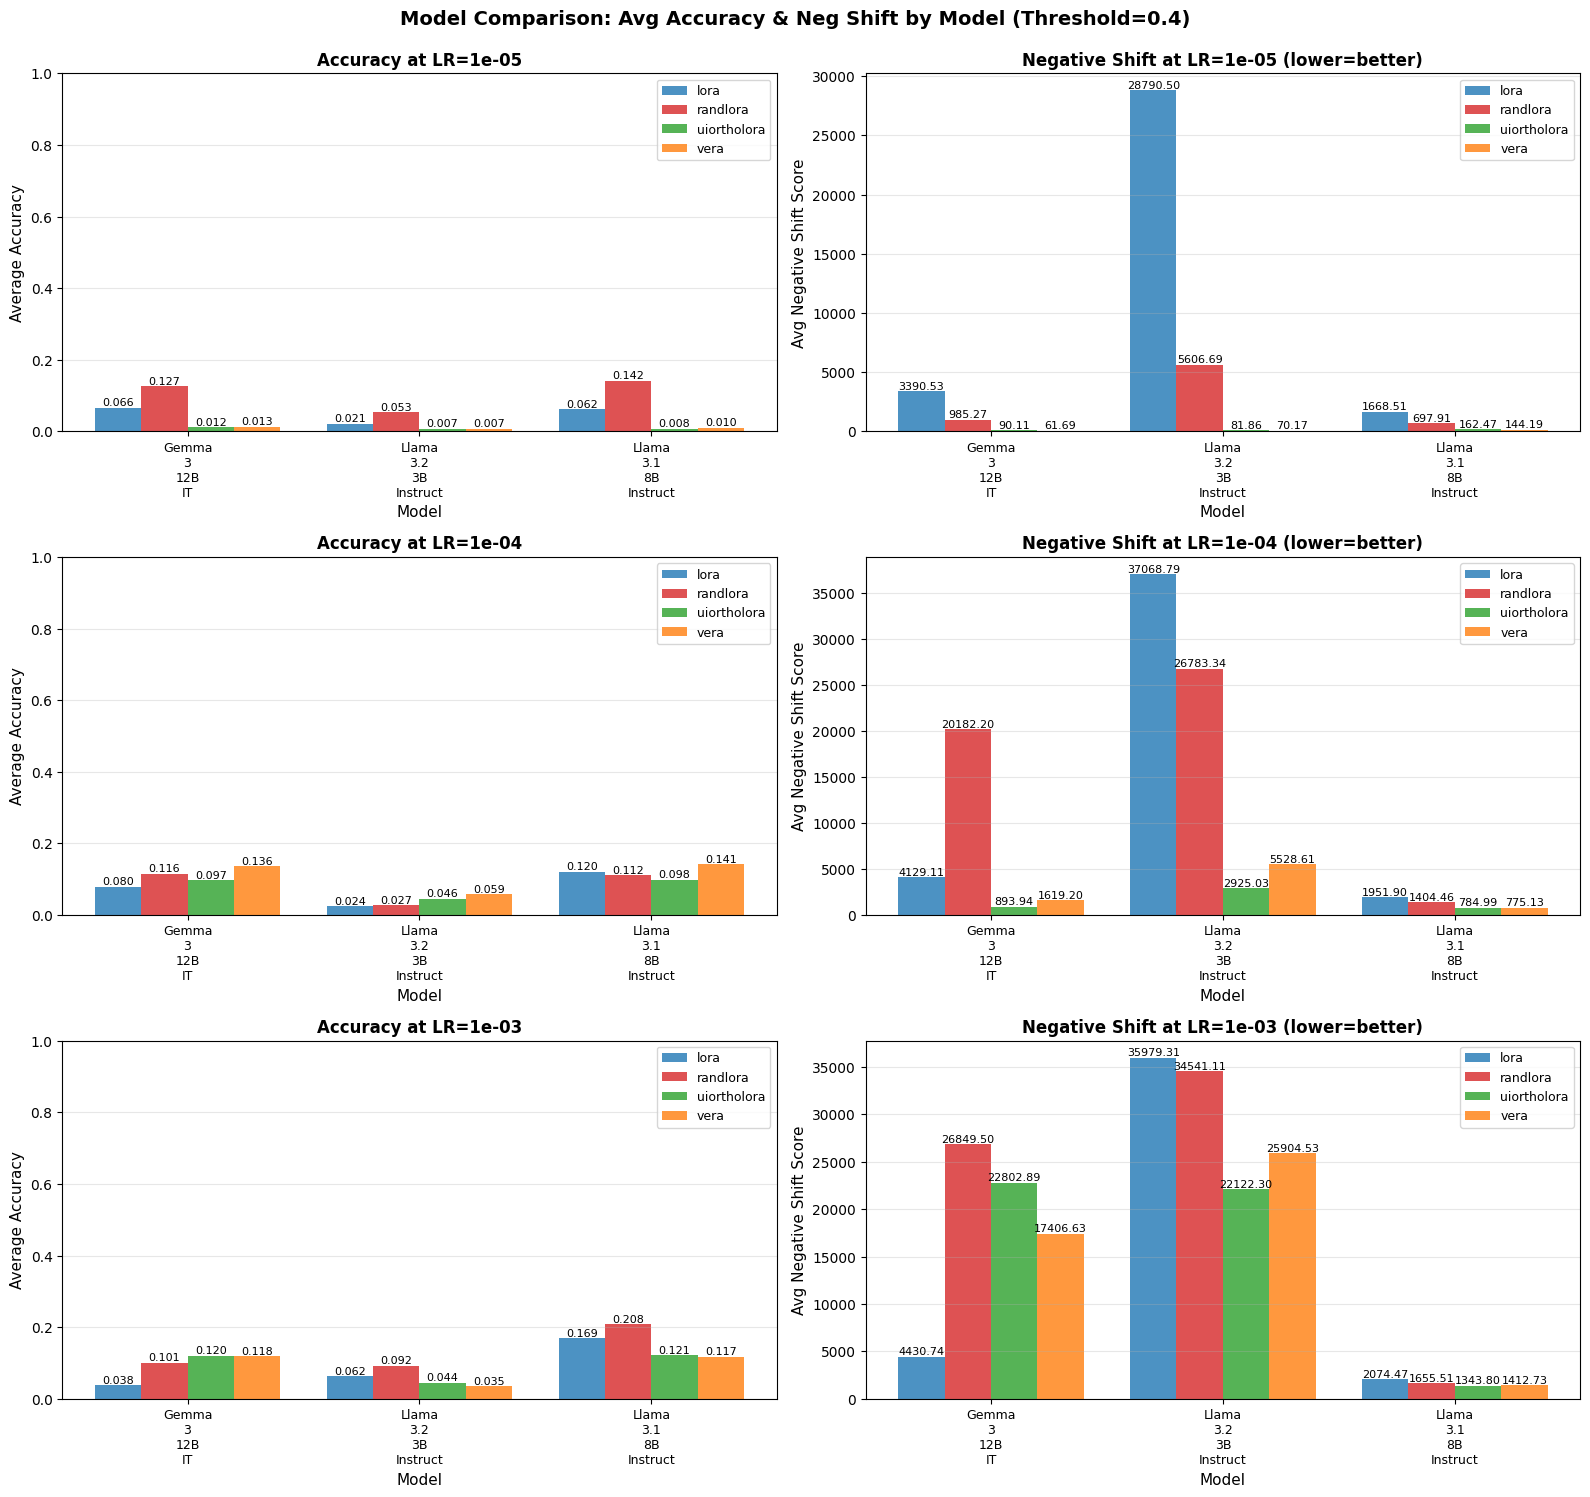

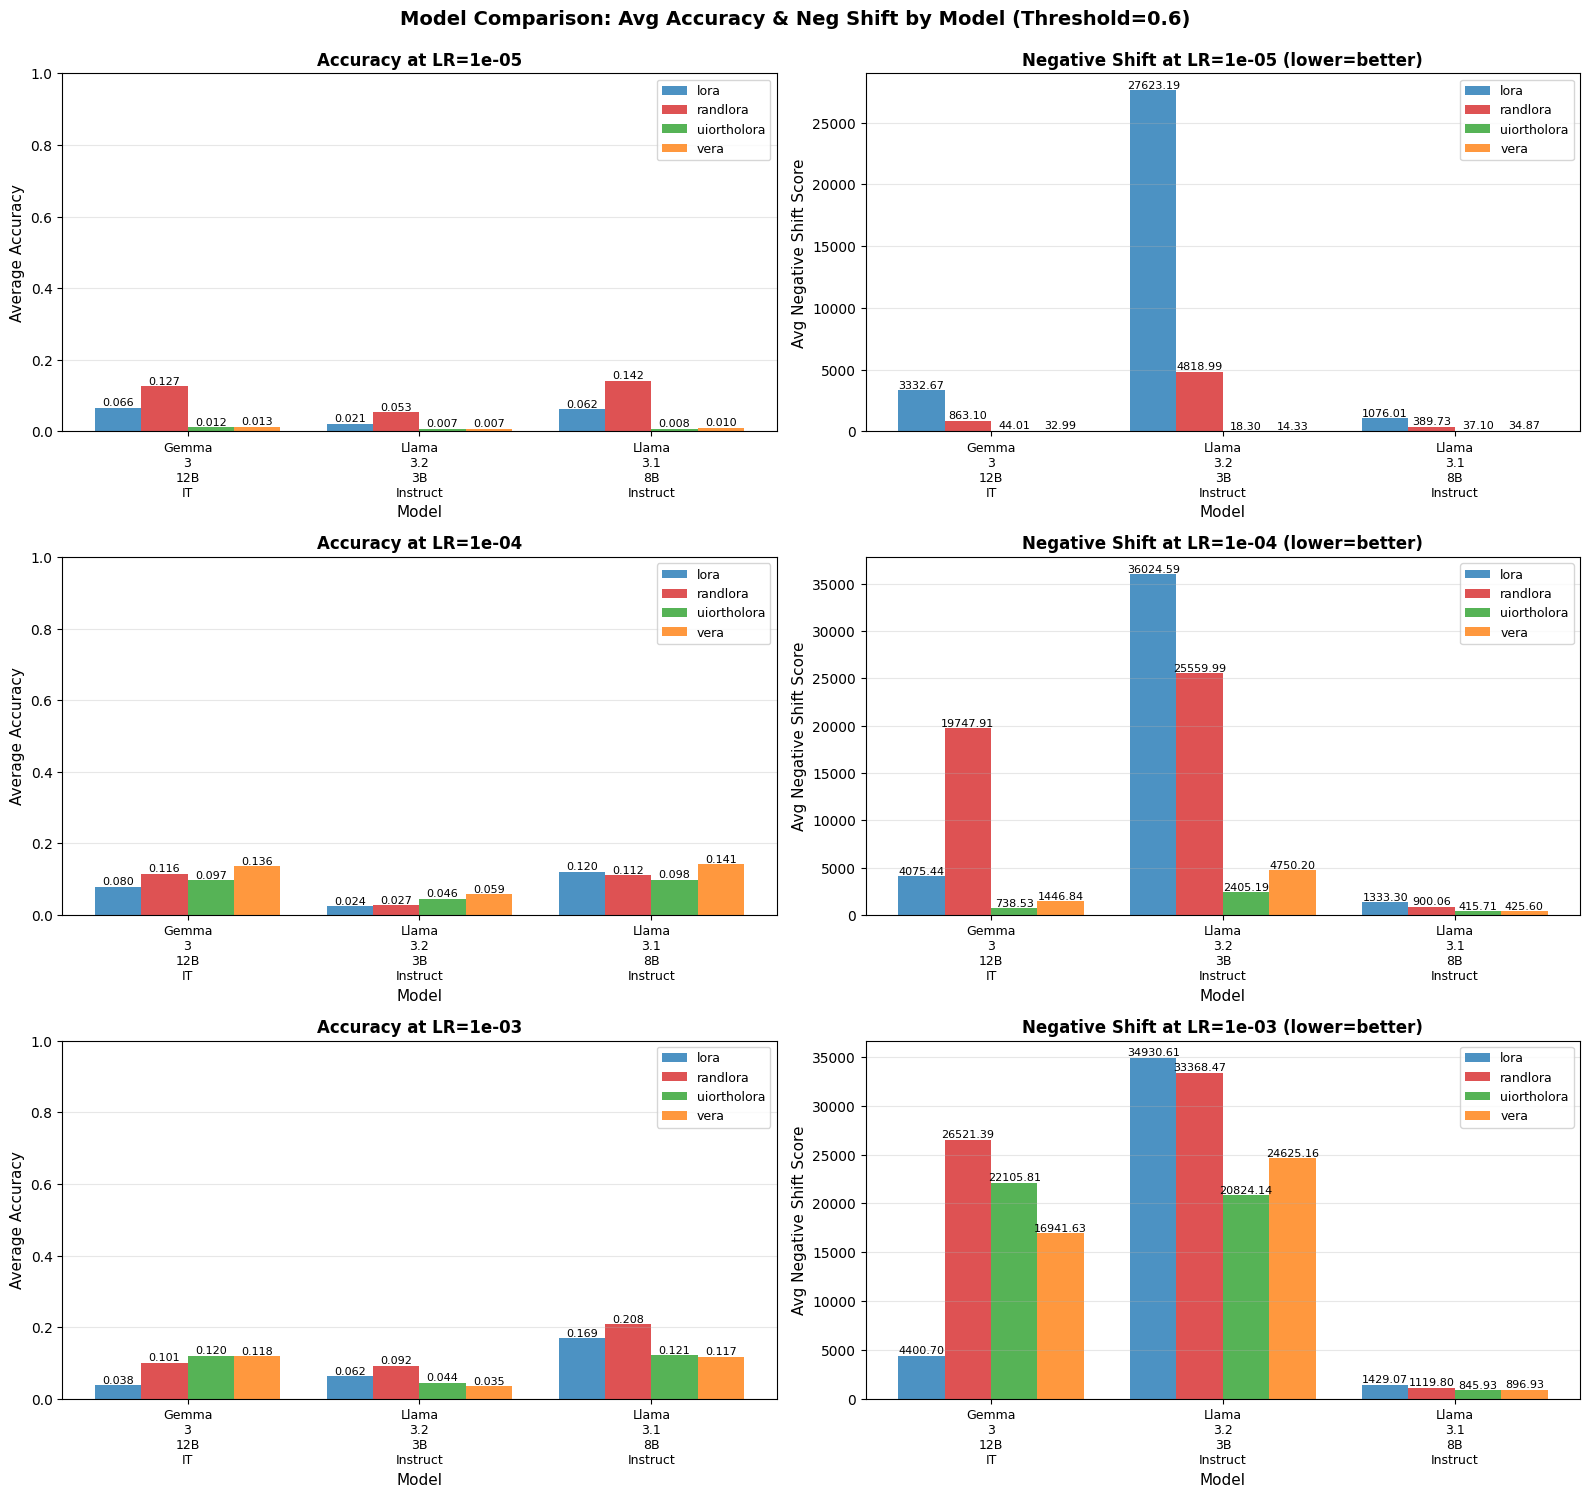

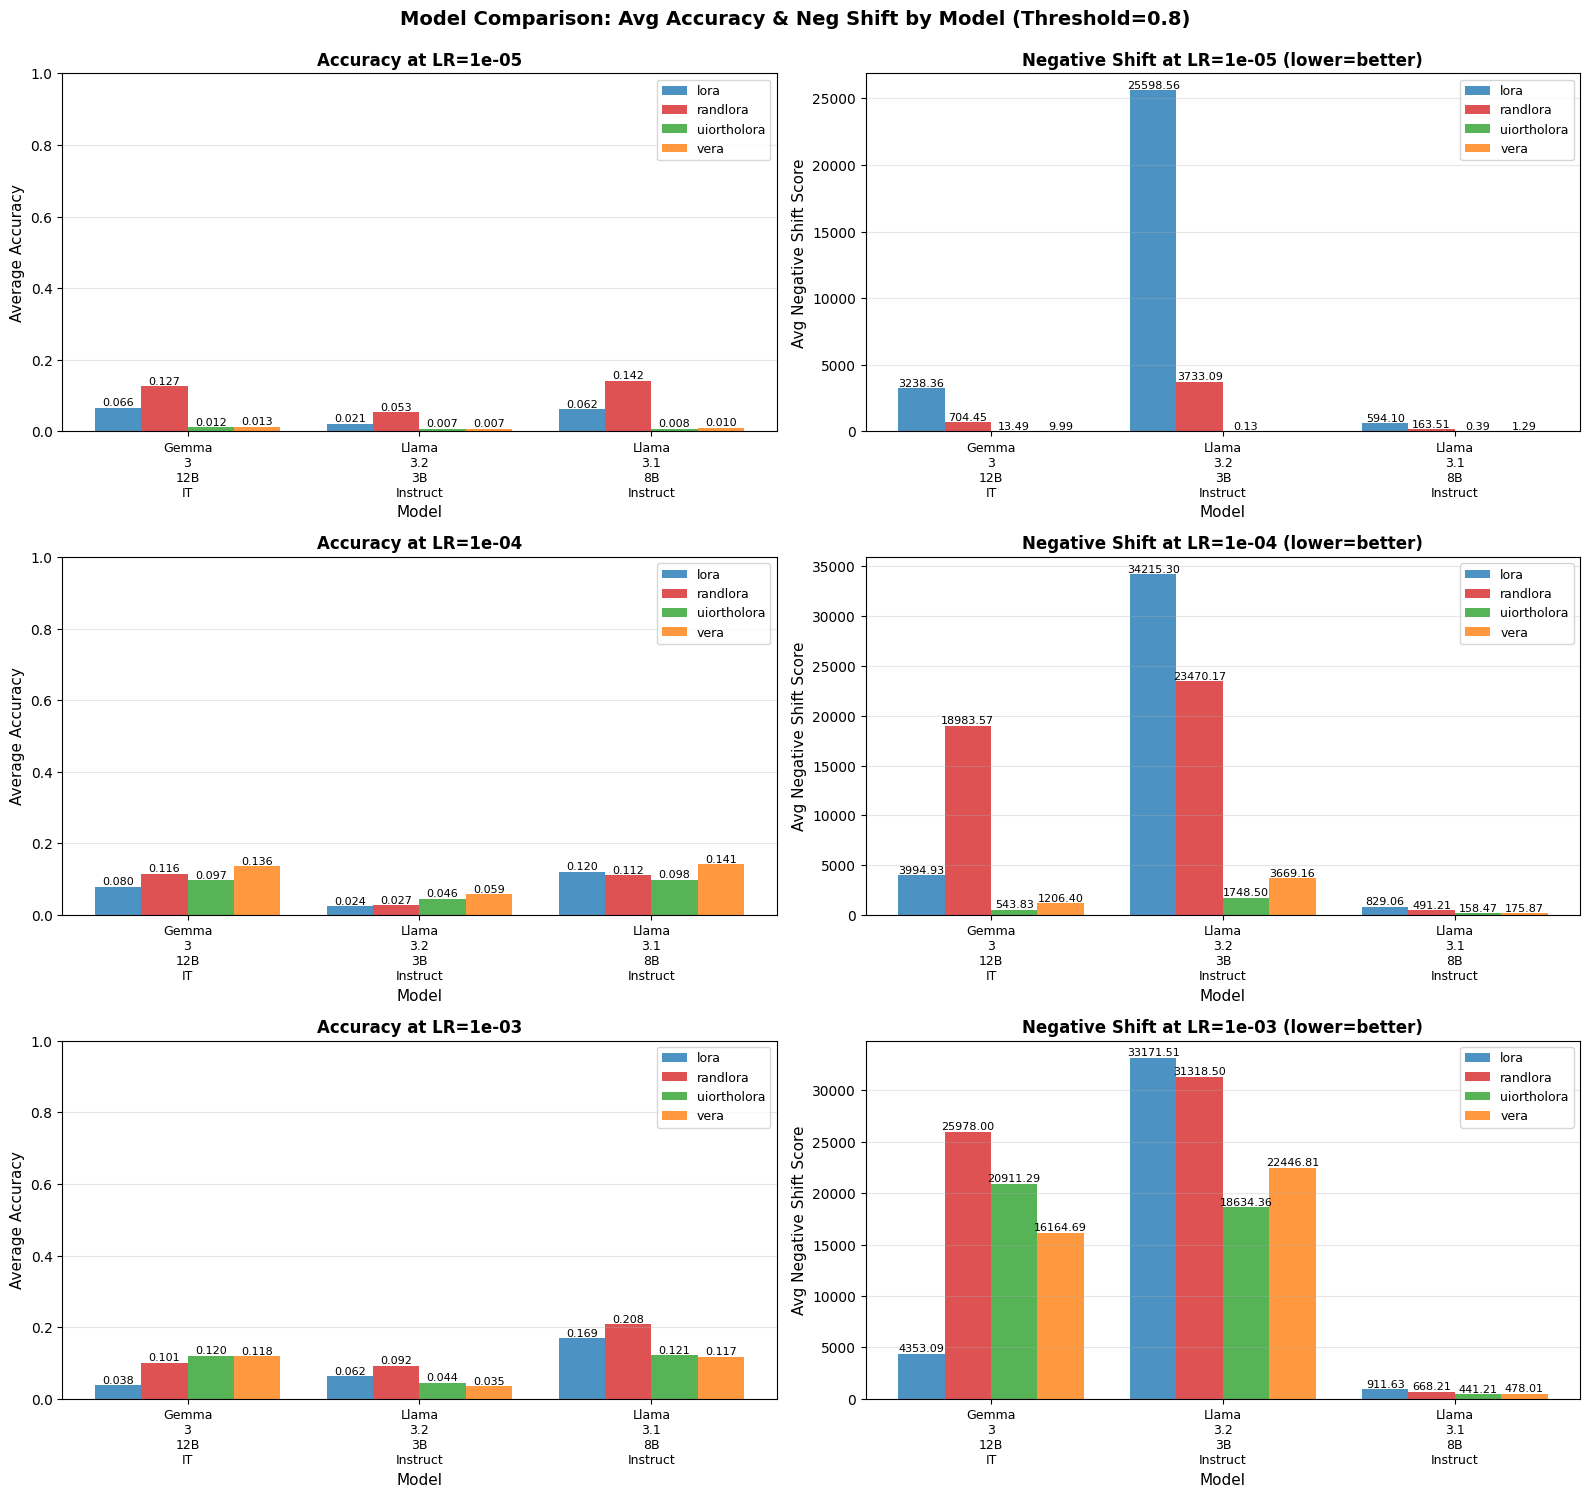


✓ Cross-model comparison complete!


In [16]:
# ============================================================================
# CROSS-MODEL COMPARISON: Average Accuracy & Negative Shift per LR
# ============================================================================

import os

def compare_models_by_lr_and_threshold():
    """
    Compare average accuracy and negative shift across models, LRs, and thresholds.
    Groups by adapter_type, model, threshold, and lr.
    """
    
    # Define model configurations
    models = [
        {
            'file_name': 'gemma-3-12b-it',
            'display_name': 'Gemma-3-12B-IT'
        },
        {
            'file_name': 'Llama-3.2-3B-Instruct',
            'display_name': 'Llama-3.2-3B-Instruct'
        },
        {
            'file_name': 'Llama-3.1-8B-Instruct',
            'display_name': 'Llama-3.1-8B-Instruct'
        }
    ]
    
    thresholds = [0.2, 0.4, 0.6, 0.8]
    
    # Collect all data
    all_data = []
    
    for model_config in models:
        for threshold in thresholds:
            csv_path = f"adapters_results/threshold_{threshold}/adapter_results_{model_config['file_name']}.csv"
            
            if not os.path.exists(csv_path):
                print(f"⚠️  File not found: {csv_path}")
                continue
            
            df = load_and_prepare_data(csv_path)
            df['model'] = model_config['display_name']
            df['threshold'] = threshold
            all_data.append(df)
    
    if not all_data:
        print("❌ No data found!")
        return
    
    # Combine all data
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Group by model, threshold, adapter_type, and lr
    # Calculate average accuracy and negative shift across training samples
    summary = combined_df.groupby(['model', 'threshold', 'adapter_type', 'lr']).agg({
        'accuracy': 'mean',
        'negative_shift_score': 'mean',
        'negative_shift_count': 'mean',
        'train_samples': 'count'  # Number of configurations
    }).reset_index()
    
    summary.columns = ['model', 'threshold', 'adapter_type', 'lr', 
                       'avg_accuracy', 'avg_neg_shift_score', 'avg_neg_shift_count', 'n_configs']
    
    # Print results per threshold
    for threshold in thresholds:
        print(f"\n{'='*100}")
        print(f"THRESHOLD = {threshold}")
        print(f"{'='*100}\n")
        
        threshold_data = summary[summary['threshold'] == threshold]
        
        for model_name in threshold_data['model'].unique():
            model_data = threshold_data[threshold_data['model'] == model_name]
            
            print(f"\n{model_name}")
            print("-" * 100)
            
            # Pivot for better readability
            pivot_acc = model_data.pivot_table(
                index='adapter_type',
                columns='lr',
                values='avg_accuracy',
                aggfunc='first'
            )
            
            pivot_neg = model_data.pivot_table(
                index='adapter_type',
                columns='lr',
                values='avg_neg_shift_score',
                aggfunc='first'
            )
            
            print("\nAverage Accuracy by Adapter & LR:")
            print(pivot_acc.to_string(float_format=lambda x: f'{x:.4f}'))
            
            print("\n\nAverage Negative Shift Score by Adapter & LR:")
            print(pivot_neg.to_string(float_format=lambda x: f'{x:.4f}'))
            print("\n")
    
    # Create visualization: Grouped bar charts for each threshold
    for threshold in thresholds:
        threshold_data = summary[summary['threshold'] == threshold]
        
        # Get unique learning rates and adapters
        unique_lrs = sorted(threshold_data['lr'].unique())
        adapters = sorted(threshold_data['adapter_type'].unique())
        model_names = [m['display_name'] for m in models]
        
        # Get adapter colors from style function
        get_style = get_adapter_styles()
        adapter_colors = [get_style(adapter)['color'] for adapter in adapters]
        
        # Create figure with subplots for each LR
        n_lrs = len(unique_lrs)
        fig, axes = plt.subplots(n_lrs, 2, figsize=(16, 5 * n_lrs))
        if n_lrs == 1:
            axes = axes.reshape(1, -1)
        
        fig.suptitle(f'Model Comparison: Avg Accuracy & Neg Shift by Model (Threshold={threshold})',
                     fontsize=14, fontweight='bold', y=0.995)
        
        for lr_idx, lr in enumerate(unique_lrs):
            lr_data = threshold_data[threshold_data['lr'] == lr]
            
            # ACCURACY SUBPLOT
            ax_acc = axes[lr_idx, 0]
            
            # X-axis: models, bars: adapters
            x = np.arange(len(model_names))
            width = 0.8 / len(adapters)  # Divide space by number of adapters
            
            for adapter_idx, adapter in enumerate(adapters):
                adapter_lr_data = lr_data[lr_data['adapter_type'] == adapter]
                
                accuracies = []
                for model_name in model_names:
                    model_data = adapter_lr_data[adapter_lr_data['model'] == model_name]
                    if not model_data.empty:
                        accuracies.append(model_data['avg_accuracy'].values[0])
                    else:
                        accuracies.append(0)
                
                offset = width * (adapter_idx - len(adapters)/2 + 0.5)
                bars = ax_acc.bar(x + offset, accuracies, width, 
                                 label=adapter, color=adapter_colors[adapter_idx], alpha=0.8)
                
                # Add value labels on bars
                for bar in bars:
                    height = bar.get_height()
                    if height > 0:
                        ax_acc.text(bar.get_x() + bar.get_width()/2., height,
                                   f'{height:.3f}',
                                   ha='center', va='bottom', fontsize=8)
            
            ax_acc.set_xlabel('Model', fontsize=11)
            ax_acc.set_ylabel('Average Accuracy', fontsize=11)
            ax_acc.set_title(f'Accuracy at LR={lr:.0e}', fontsize=12, fontweight='bold')
            ax_acc.set_xticks(x)
            ax_acc.set_xticklabels([m.replace('-', '\n') for m in model_names], fontsize=9)
            ax_acc.legend(loc='best', fontsize=9)
            ax_acc.grid(axis='y', alpha=0.3)
            ax_acc.set_ylim([0, 1.0])
            
            # NEGATIVE SHIFT SUBPLOT
            ax_neg = axes[lr_idx, 1]
            
            for adapter_idx, adapter in enumerate(adapters):
                adapter_lr_data = lr_data[lr_data['adapter_type'] == adapter]
                
                neg_shifts = []
                for model_name in model_names:
                    model_data = adapter_lr_data[adapter_lr_data['model'] == model_name]
                    if not model_data.empty:
                        neg_shifts.append(model_data['avg_neg_shift_score'].values[0])
                    else:
                        neg_shifts.append(0)
                
                offset = width * (adapter_idx - len(adapters)/2 + 0.5)
                bars = ax_neg.bar(x + offset, neg_shifts, width,
                                 label=adapter, color=adapter_colors[adapter_idx], alpha=0.8)
                
                # Add value labels on bars
                for bar in bars:
                    height = bar.get_height()
                    if height > 0:
                        ax_neg.text(bar.get_x() + bar.get_width()/2., height,
                                   f'{height:.2f}',
                                   ha='center', va='bottom', fontsize=8)
            
            ax_neg.set_xlabel('Model', fontsize=11)
            ax_neg.set_ylabel('Avg Negative Shift Score', fontsize=11)
            ax_neg.set_title(f'Negative Shift at LR={lr:.0e} (lower=better)', fontsize=12, fontweight='bold')
            ax_neg.set_xticks(x)
            ax_neg.set_xticklabels([m.replace('-', '\n') for m in model_names], fontsize=9)
            ax_neg.legend(loc='best', fontsize=9)
            ax_neg.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'graphs/comparison_bars_threshold_{threshold}.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    return summary

# Run the comparison
summary_df = compare_models_by_lr_and_threshold()

print("\n✓ Cross-model comparison complete!")